<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW4_woodenML_base_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание 4 (base): древесные алгоритмы**

### **Постановка задачи:**

У вас есть данные о полетах, обладающие следущими характеристиками:
- Для **каждого** клиента известна краткая информация о самом человеке, о типе билета и о рейсе, а также оценки клиента различным аспектам полета.
- Для **некоторых** клиентов известна их удовлетворенность полетом (satisfied или neutral or dissatisfied).

По данным необходимо обучить модель, предсказывающую удовлетворенность клиентов полетом. Итоговые предсказания нужно сделать для клиентов, **для которых ответ неизвестен.**

### **Получение данных:**

Компания держит все данные в облаке Яндекса в Postgresql. Данные разбиты на смысловые таблицы. Чтобы получить данные, вам необходимо подключиться к базе данных и добыть оттуда данные.

### **Оценивание:**

- Как всегда оцениваются как код, так и ответы на вопросы. Если нет одного и/или другого, то часть баллов за соответствующее задание без колебаний снимается.
- Брать код из открытых источников позволительно. Следование культуре цитирования **обязательно.**

### **Баллы:**

Суммарно за задание можно получить 10 основных и 0.7 бонусных баллов.

Оценка за ДЗ = min{ваш балл, 10}

Мягкий дедлайн: 29 января 23:59

**Продуктивной и интересной вам работы!**

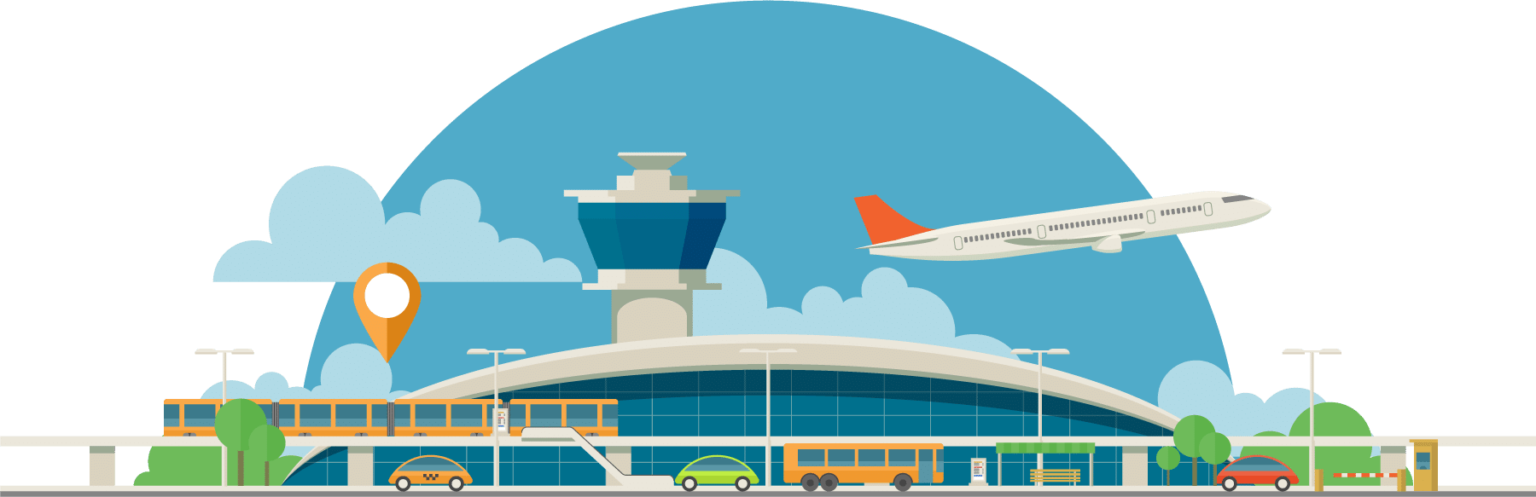

In [1]:
# установка всех библиотек, необходимых для выполнения ДЗ

!pip install catboost
!pip install mlxtend --upgrade
!pip install optuna
!pip install lime
!pip install shap
!pip install missingno
!pip install psycopg2-binary
#!pip install xgboost
#!brew install cmake libomp
#!pip install lightgbm

  Using cached numpy-2.4.1-cp313-cp313-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached numpy-2.4.1-cp313-cp313-macosx_14_0_arm64.whl (5.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.1.3
    Uninstalling numpy-2.1.3:
      Successfully uninstalled numpy-2.1.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.1 which is incompatible.
spacy-transformers 1.3.9 requires transformers<4.50.0,>=3.4.0, but you have transformers 4.57.1 which is incompatible.
streamlit 1.45.1 requires pandas<3,>=1.4.0, but you have pandas 3.0.0 which is incompatible.
statsforecast 2.0.3 requires scipy<1.16.0,>=1.7.3, but you have scipy 1.17.0 which is incompatible.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.4.1 which is incompatible.
ydata-p

In [2]:
!pip install xgboost
!brew install cmake libomp
!pip install lightgbm

zsh:1: command not found: brew


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import missingno

import psycopg2
import psycopg2.extras

from mlxtend.plotting import plot_decision_regions
from mlxtend.evaluate import bias_variance_decomp
from graphviz import Source
from sklearn.tree import export_graphviz
from IPython.display import SVG

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.calibration import CalibrationDisplay
from sklearn.isotonic import IsotonicRegression

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, mutual_info_classif
from sklearn.feature_selection import SequentialFeatureSelector, RFE, SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.base import TransformerMixin, BaseEstimator

import shap
import lime
import lime.lime_tabular

import optuna

import pickle

np.random.seed(42)

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [4]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) #на середине дз стали бесить...
warnings.filterwarnings("ignore", category=RuntimeWarning) #на середине дз стали бесить...

# **Часть 1: Получение данных, обработка и EDA (2.75 балла)**

В этой части вам необходимо:
- Загрузить данные из БД и предобработать их (1.75 бала)
- Провести разведочный анализ данных (1. балл)

## **1. 1. Загрузка и предобработка данных (1.75 балла)**

In [5]:
!mkdir -p ~/.postgresql && \
wget "https://storage.yandexcloud.net/cloud-certs/CA.pem" \
    --output-document ~/.postgresql/root.crt && \
chmod 0600 ~/.postgresql/root.crt

zsh:1: command not found: wget


У меня мак, сделала через curl 

### **Задание 1. Получение данных (0.5 балла)**

- Подключитесь к БД при помощи `psycopg2.connect()`
- Напишите SQL-запрос, объединяющий 3 нужные таблицы в одну
- Результат запроса поместите в `pd.DataFrame`. Индексом получившегося датафрейма сделайте столбец 'id'.

Список столбцов таблиц добудьте самостоятельно.


**Примечание:**
 Не забудьте закрыть соединение. Или открывайте соединение, используя менеджер контекста `with as`, который закроет его автоматически

##### **Параметры соединения:**
```
host=rc1b-70q90cunwkzx49mj.mdb.yandexcloud.net
port=6432
sslmode=verify-full
dbname=db_flights
user=mlhs_student
password=mlhs_student
target_session_attrs=read-write```
```

##### **Схема БД**

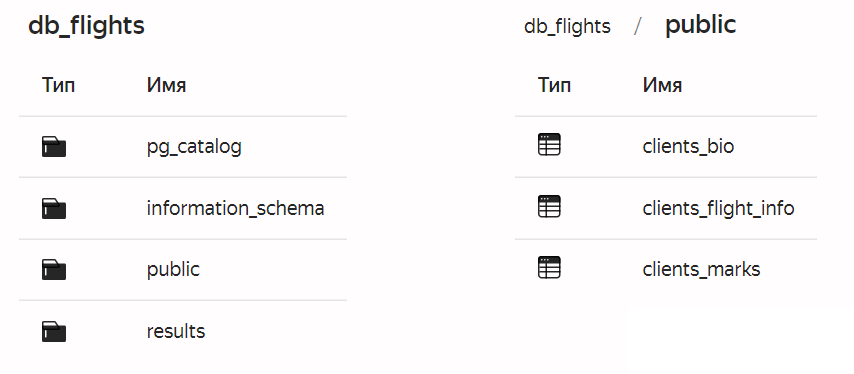



In [6]:
conn = psycopg2.connect(
    host="rc1b-70q90cunwkzx49mj.mdb.yandexcloud.net",
    port=6432,
    sslmode="verify-full",
    dbname="db_flights",
    user="mlhs_student",
    password="mlhs_student",
    target_session_attrs="read-write"
)



In [7]:
query = """
select * 
from public.clients_bio
"""

print(pd.read_sql(query, conn))


query = """
select * 
from public.clients_flight_info
"""

print(pd.read_sql(query, conn))


query = """
select * 
from public.clients_marks
"""

print(pd.read_sql(query, conn))



            id  gender   age
0            1    Male  48.0
1            2  Female  35.0
2            3    Male  41.0
3            4    Male  50.0
4            5  Female  49.0
...        ...     ...   ...
129544  129876    Male  28.0
129545  129877    Male  41.0
129546  129878    Male  42.0
129547  129879    Male  50.0
129548  129880  Female  20.0

[129549 rows x 3 columns]
            id      Customer Type   Type of Travel     class Flight Distance  \
0            1  disloyal Customer  Business travel  Business           821.0   
1            2     Loyal Customer  Business travel  Business           821.0   
2            3     Loyal Customer  Business travel  Business           853.0   
3            4     Loyal Customer  Business travel  Business          1905.0   
4            5     Loyal Customer  Business travel  Business          3470.0   
...        ...                ...              ...       ...             ...   
129875  129876     Loyal Customer  Personal Travel  Eco Plus     

In [8]:
conn.close()

Ну кстати по таблицам видно, что не у всех клиентов есть био, так что я сначала думала делать джоин на таблицу где больше id. 

Делаю запрос не через селект зведочка, так как во всех колонках есть id, а там нужны они только с первой таблицы

In [9]:
query = """
SELECT
    b.id,
    b.gender,
    b.age,
    f."Customer Type",
    f."Type of Travel",
    f.class,
    f."Flight Distance",
    f."Departure Delay in Minutes",
    f."Arrival Delay in Minutes",
    m."Inflight wifi service",
    m."Departure/Arrival time convenient",
    m."Ease of Online booking",
    m."Gate location",
    m."Food and drink",
    m."Online boarding",
    m."Seat comfort",
    m."Inflight entertainment",
    m."On-board service",
    m."Leg room service",
    m."Baggage handling",
    m."Checkin service",
    m."Inflight service",
    m.cleanliness,
    m.satisfaction
from public.clients_bio b
left join public.clients_flight_info f
    ON b.id = f.id
left join public.clients_marks m
    ON b.id = m.id;
"""

with psycopg2.connect(
    host="rc1b-70q90cunwkzx49mj.mdb.yandexcloud.net",
    port=6432,
    sslmode="verify-full",
    dbname="db_flights",
    user="mlhs_student",
    password="mlhs_student",
    target_session_attrs="read-write"
) as conn:
    df = pd.read_sql(query, conn)

df.set_index("id", inplace=True)


In [10]:
assert df.shape == (129_549, 23)

### **Задание 2 (0.25 балла)**

- Преобразуйте числовые столбцы в `float`. Проверьте, есть ли в датафрейме пропуски и выбросы (в том числе в категориальных признаках)</font>.

In [11]:
# Ваш код ниже
df.info()

<class 'pandas.DataFrame'>
Index: 129549 entries, 7 to 129876
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype
---  ------                             --------------   -----
 0   gender                             129549 non-null  str  
 1   age                                129549 non-null  str  
 2   Customer Type                      129549 non-null  str  
 3   Type of Travel                     129549 non-null  str  
 4   class                              129549 non-null  str  
 5   Flight Distance                    129549 non-null  str  
 6   Departure Delay in Minutes         129549 non-null  str  
 7   Arrival Delay in Minutes           129549 non-null  str  
 8   Inflight wifi service              129549 non-null  str  
 9   Departure/Arrival time convenient  129549 non-null  str  
 10  Ease of Online booking             129549 non-null  str  
 11  Gate location                      129549 non-null  str  
 12  Food and drink    

Почему-то все колонки типа str, строкового...

In [12]:
df.head()

,gender,age,Customer Type,Type of Travel,class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,Departure/Arrival time convenient,...,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,cleanliness,satisfaction
id,,,,,,,,,,,,,,,,,,,,,
7,Male,43.0,Loyal Customer,Business travel,Business,1963.0,0.0,0.0,3.0,3.0,...,4.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,4.0,satisfied
13,Male,24.0,disloyal Customer,Business travel,Eco,453.0,16.0,30.0,2.0,2.0,...,2.0,5.0,5.0,2.0,4.0,4.0,2.0,4.0,5.0,neutral or dissatisfied
18,Female,61.0,Loyal Customer,Personal Travel,Eco,821.0,0.0,0.0,2.0,5.0,...,1.0,5.0,5.0,5.0,2.0,5.0,5.0,5.0,1.0,neutral or dissatisfied
31,Male,35.0,disloyal Customer,Business travel,Business,212.0,0.0,0.0,2.0,2.0,...,2.0,2.0,2.0,4.0,5.0,5.0,5.0,4.0,2.0,neutral or dissatisfied
39,Female,46.0,Loyal Customer,Business travel,Business,67.0,0.0,0.0,3.0,3.0,...,5.0,4.0,4.0,4.0,4.0,4.0,5.0,4.0,5.0,satisfied


Преобразуем все, что должно быть числовым во float 

In [13]:
num_cols = [
    'age',
    'Flight Distance',
    'Departure Delay in Minutes',
    'Arrival Delay in Minutes',
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'cleanliness'
]

for col in num_cols:
    df[col] = df[col].astype(float)

df[num_cols].dtypes


age                                  float64
Flight Distance                      float64
Departure Delay in Minutes           float64
Arrival Delay in Minutes             float64
Inflight wifi service                float64
Departure/Arrival time convenient    float64
Ease of Online booking               float64
Gate location                        float64
Food and drink                       float64
Online boarding                      float64
Seat comfort                         float64
Inflight entertainment               float64
On-board service                     float64
Leg room service                     float64
Baggage handling                     float64
Checkin service                      float64
Inflight service                     float64
cleanliness                          float64
dtype: object

In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 129549 entries, 7 to 129876
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   gender                             129549 non-null  str    
 1   age                                129234 non-null  float64
 2   Customer Type                      129549 non-null  str    
 3   Type of Travel                     129549 non-null  str    
 4   class                              129549 non-null  str    
 5   Flight Distance                    129455 non-null  float64
 6   Departure Delay in Minutes         129442 non-null  float64
 7   Arrival Delay in Minutes           129042 non-null  float64
 8   Inflight wifi service              129505 non-null  float64
 9   Departure/Arrival time convenient  129500 non-null  float64
 10  Ease of Online booking             129506 non-null  float64
 11  Gate location                      129512 non-null  flo

После преобразования у нас появились пропуски в числовых данных, посмотрим на выбросы

In [15]:
df.describe(include='all')

,gender,age,Customer Type,Type of Travel,class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,Departure/Arrival time convenient,...,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,cleanliness,satisfaction
count,129549,129234.000000,129549,129549,129549,129455.000000,129442.000000,129042.000000,129505.000000,129500.000000,...,129503.000000,129502.000000,129504.000000,129505.000000,129503.000000,129501.000000,129507.000000,129486.000000,129512.000000,129549
unique,2,NaN,3,3,4,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,Female,NaN,Loyal Customer,Business travel,Business,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral or dissatisfied
freq,65726,NaN,105763,89405,61939,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58732
mean,NaN,40.116951,NaN,NaN,NaN,1322.922158,15.809026,16.656499,2.732327,3.062131,...,3.256782,3.445669,3.361232,3.387259,3.355976,3.635872,3.309976,3.646927,3.289780,NaN
std,NaN,20.376129,NaN,NaN,NaN,4517.816532,93.276882,109.285072,1.360033,1.559627,...,1.381888,1.349713,1.366908,1.335697,1.361670,1.222039,1.298827,1.218748,1.347466,NaN
min,NaN,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,27.000000,NaN,NaN,NaN,414.000000,0.000000,0.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,NaN
50%,NaN,40.000000,NaN,NaN,NaN,846.000000,0.000000,0.000000,3.000000,3.000000,...,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,NaN
75%,NaN,51.000000,NaN,NaN,NaN,1744.000000,12.000000,13.000000,4.000000,4.000000,...,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,NaN


- По gender все выглядит равновешанно, женщин чуть побольше. 
- В age видим выброс 621, выглядит как ошибка. при том что остальные перцентили выглядт адекватно. 
- В Customer Type видно, что больше всего лояльных покупателей. 
- Всего 4 class и больше всего выбирают Business Travel
- Что касается выбросов, то во Flight Distance видно очень большой максимум при 75 перцентиле 1744 максимум 379620, что говорит о том что это явная ошибка. 
- Во Depature Delay in Minutes, Arrival Delay in Miutes также максимальные значения огромны, с учетом что медиана у них составляет 0, это аномально большие задержки (75 перцентиль около10). 
- Все колонки, которые показывают оценки (от Ease of Online Booking до cleanliness) будто бы должны быть от 1 до 5, но у них максимумы больше этих значений, что тоже странно и может являться ошибкой
- Таргет у нас представлен 3 вариантами, больше всего ставят нейтрально/недоволен, что составляет почти половину от всех ответов 

### **Задание 3 (0.5 балла)**

Воспользуйтесь модулем `missingno` для визуализации пропусков в датафрейме. Постройте:
-  `matrix` пропущенных значений;
- столбчатую диаграмму в **логарифмированной** шкале (так как пропусков немного, по обычной не будет видно, в каких столбцах их больше)

<Figure size 1000x500 with 0 Axes>

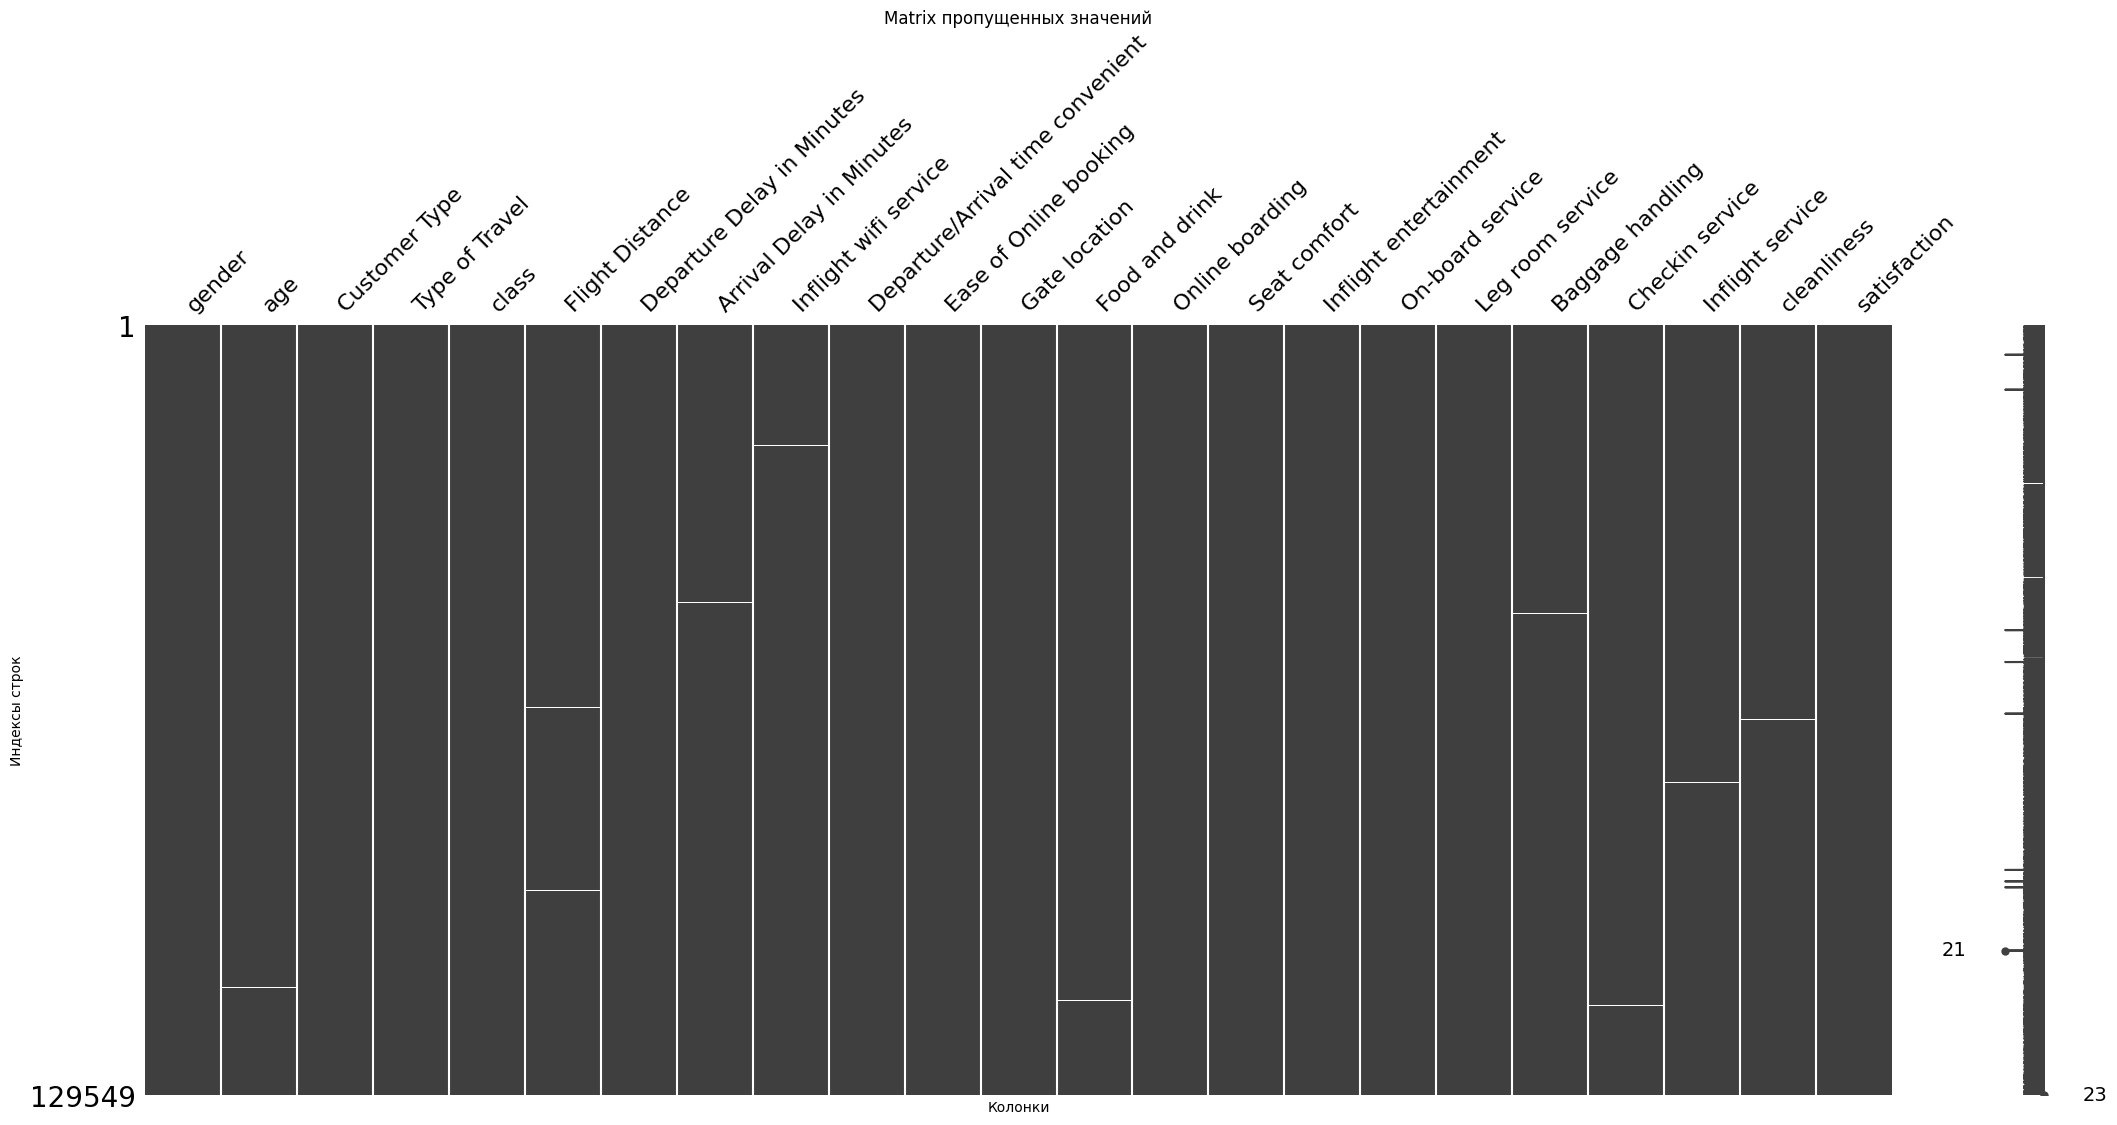

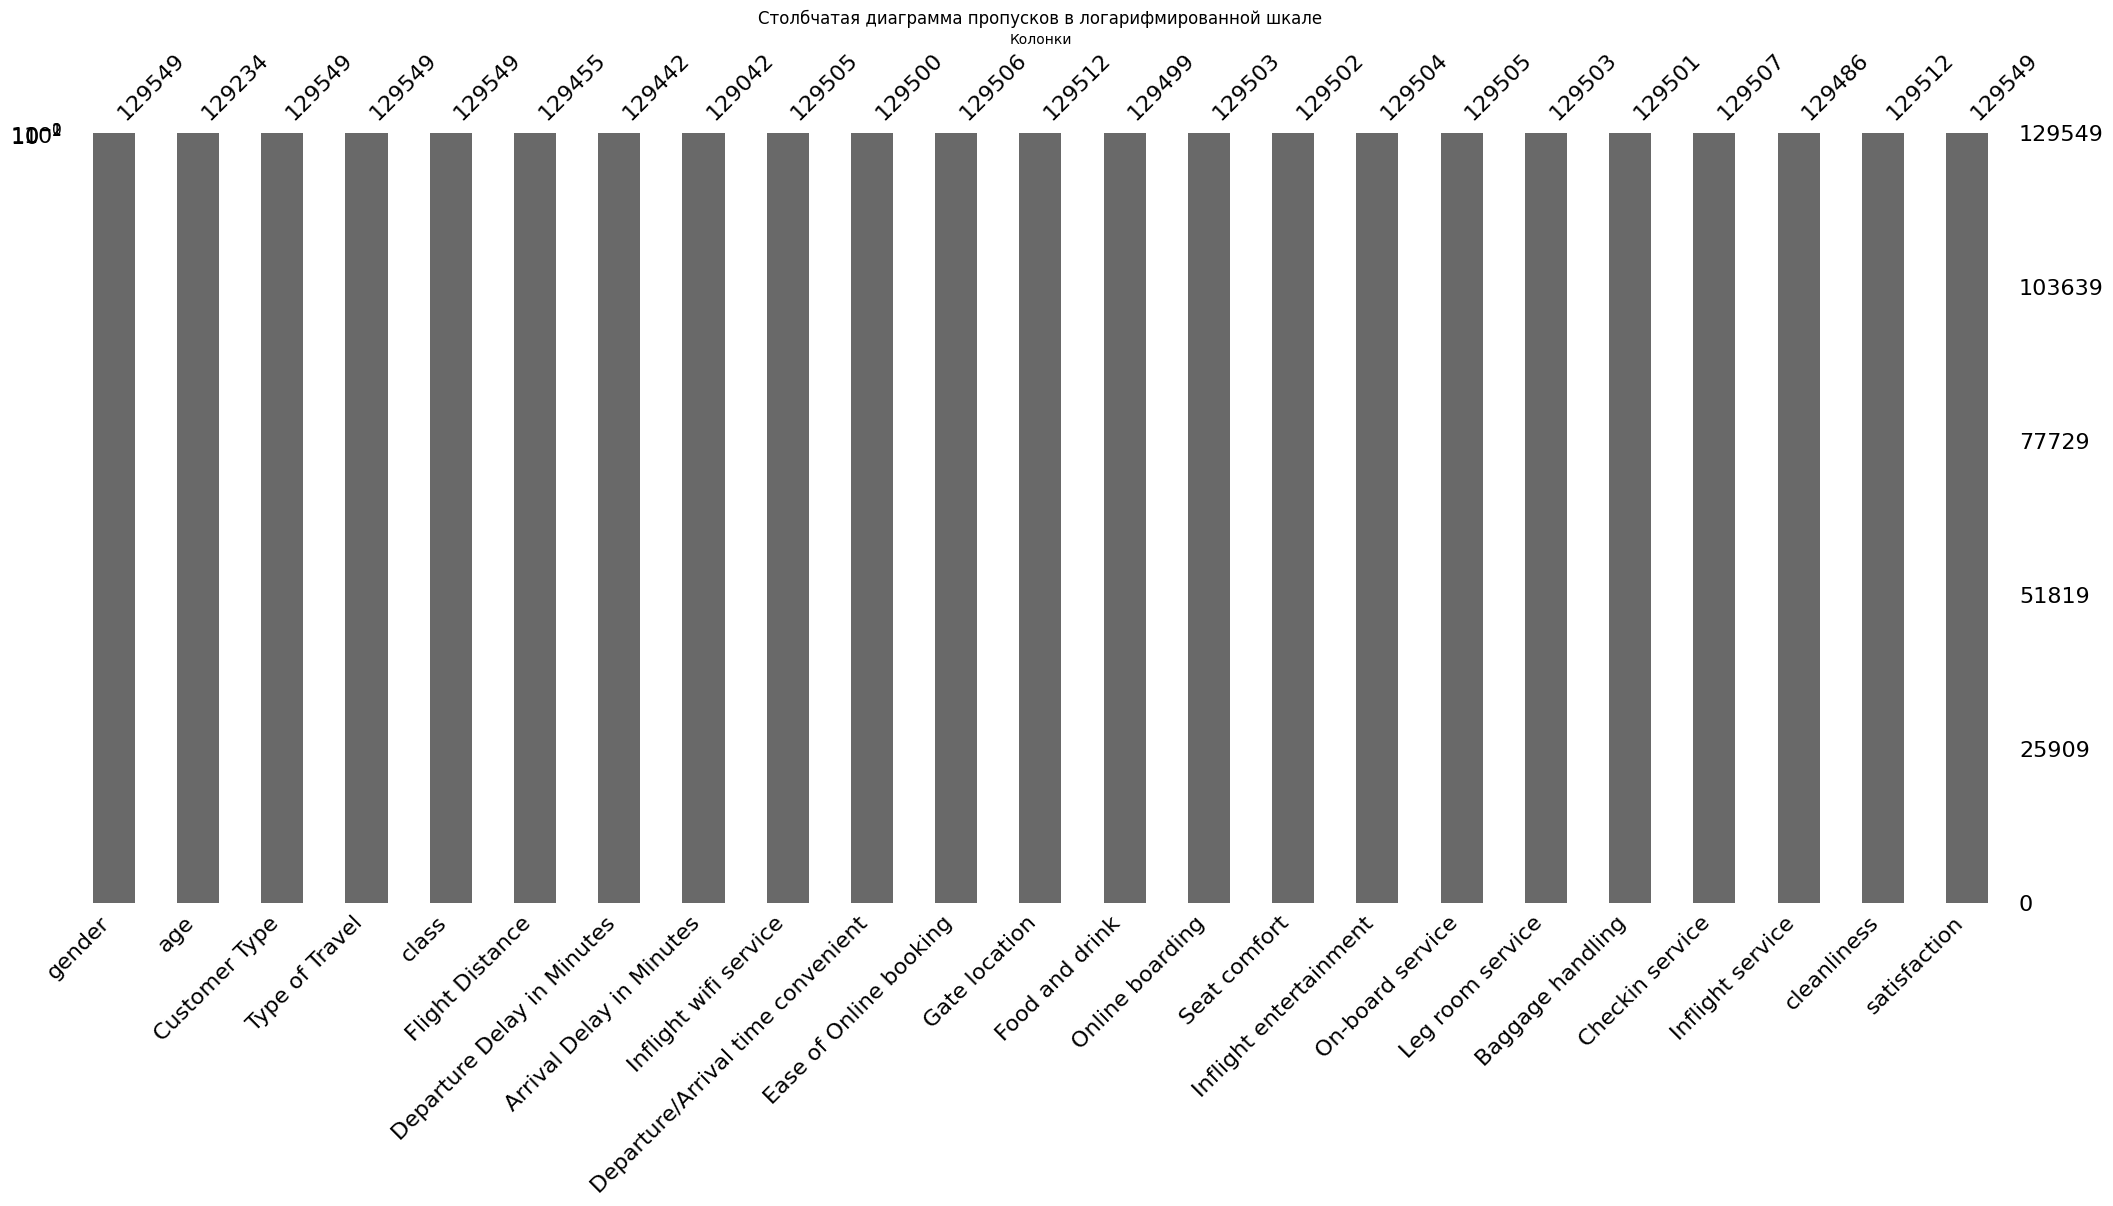

In [16]:
# Ваш код ниже

plt.figure(figsize=(10, 5))
missingno.matrix(df,)
plt.title("Matrix пропущенных значений")
plt.xlabel("Колонки")
plt.ylabel("Индексы строк")
plt.show()

plt.figure(figsize=(10, 5))
missingno.bar(df)
plt.yscale('log')
plt.title("Столбчатая диаграмма пропусков в логарифмированной шкале")
plt.xlabel("Колонки") 
plt.ylabel("Количество непустых значений (логарифм)") #чего то не получается увидеть эту подпись на графике
plt.show()

Разобьем датасет на тренировочную и тестовую части. Тестовую часть отложим надолго -- до самого конца этого ноутбука.

In [17]:
df_train = df[df.satisfaction != '-']
df_train

,gender,age,Customer Type,Type of Travel,class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,Departure/Arrival time convenient,...,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,cleanliness,satisfaction
id,,,,,,,,,,,,,,,,,,,,,
7,Male,43.0,Loyal Customer,Business travel,Business,1963.0,0.0,0.0,3.0,3.0,...,4.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,4.0,satisfied
13,Male,24.0,disloyal Customer,Business travel,Eco,453.0,16.0,30.0,2.0,2.0,...,2.0,5.0,5.0,2.0,4.0,4.0,2.0,4.0,5.0,neutral or dissatisfied
18,Female,61.0,Loyal Customer,Personal Travel,Eco,821.0,0.0,0.0,2.0,5.0,...,1.0,5.0,5.0,5.0,2.0,5.0,5.0,5.0,1.0,neutral or dissatisfied
31,Male,35.0,disloyal Customer,Business travel,Business,212.0,0.0,0.0,2.0,2.0,...,2.0,2.0,2.0,4.0,5.0,5.0,5.0,4.0,2.0,neutral or dissatisfied
39,Female,46.0,Loyal Customer,Business travel,Business,67.0,0.0,0.0,3.0,3.0,...,5.0,4.0,4.0,4.0,4.0,4.0,5.0,4.0,5.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129831,Female,28.0,Loyal Customer,Personal Travel,Eco,447.0,23.0,16.0,1.0,3.0,...,1.0,3.0,3.0,1.0,1.0,4.0,1.0,5.0,3.0,neutral or dissatisfied
129837,Male,66.0,Loyal Customer,Personal Travel,Eco,337.0,199.0,213.0,2.0,4.0,...,5.0,5.0,5.0,2.0,4.0,5.0,5.0,4.0,5.0,neutral or dissatisfied
129838,Female,59.0,Loyal Customer,Personal Travel,Eco,308.0,32.0,24.0,3.0,5.0,...,5.0,5.0,3.0,3.0,3.0,3.0,4.0,3.0,4.0,neutral or dissatisfied


In [18]:
assert df_train.shape == (103_644, 23)

In [19]:
df_test = df[df.satisfaction == '-'].drop('satisfaction', axis=1)
df_test

,gender,age,Customer Type,Type of Travel,class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,Departure/Arrival time convenient,...,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,cleanliness
id,,,,,,,,,,,,,,,,,,,,,
55,Male,36.0,Loyal Customer,Business travel,Business,3655.0,40.0,71.0,1.0,1.0,...,1.0,3.0,3.0,3.0,3.0,3.0,1.0,4.0,3.0,2.0
79,Female,70.0,Loyal Customer,Personal Travel,Eco,108.0,50.0,41.0,5.0,4.0,...,4.0,4.0,4.0,3.0,3.0,0.0,3.0,5.0,3.0,5.0
126,Male,66.0,Loyal Customer,Personal Travel,Eco,562.0,88.0,84.0,2.0,5.0,...,5.0,2.0,5.0,5.0,3.0,5.0,2.0,5.0,5.0,5.0
199,Female,60.0,Loyal Customer,Business travel,Business,3756.0,36.0,24.0,4.0,4.0,...,2.0,4.0,5.0,4.0,4.0,4.0,4.0,5.0,4.0,5.0
263,Male,43.0,Loyal Customer,Personal Travel,Business,802.0,0.0,0.0,1.0,2.0,...,2.0,3.0,3.0,2.0,2.0,1.0,2.0,3.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129750,Male,38.0,Loyal Customer,Business travel,Eco,337.0,92.0,82.0,4.0,3.0,...,4.0,5.0,4.0,4.0,4.0,5.0,4.0,5.0,3.0,4.0
129771,Male,16.0,Loyal Customer,Personal Travel,Eco,308.0,2.0,0.0,3.0,4.0,...,1.0,3.0,5.0,1.0,4.0,2.0,5.0,5.0,4.0,1.0
129798,Female,43.0,Loyal Customer,Personal Travel,Eco,308.0,0.0,0.0,2.0,4.0,...,3.0,5.0,5.0,4.0,4.0,2.0,4.0,4.0,4.0,5.0


In [20]:
assert df_test.shape == (25_905, 22)

Разбиваем данные на трейн и валидацию. Не меняйте сид

In [21]:
X_train, X_val, y_train, y_val = train_test_split(df_train.drop('satisfaction', axis=1), df_train.satisfaction, test_size=0.3, random_state=42)

In [22]:
assert X_train.shape == (72_550, 22)
assert X_val.shape == (31_094, 22)

### **Задание 4. (0.15 балла)**

Заполните пропуски в данных наиболее часто встречающимся значением.
Помните про правильность заполнения.

**Примечание:** Мы также могли восстановать пропуски `KNNImputer`'ом или `IterativeImputer`'ом. Как правило, такое заполнение точнее и лучше сохраняет структуру распределений. Но для признаков в нашей задаче Imputer'ы, реализованные библиотечно не подошли бы. Они возвращали бы вещественные значения, а в нашей задаче все признаки целые.

In [23]:
# Ваш код ниже
print(X_train.isna().sum().sum())
print(X_val.isna().sum().sum())

925
402


In [24]:
imputer = SimpleImputer(strategy='most_frequent')

X_train_imputer = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_val_imputer = pd.DataFrame(
    imputer.transform(X_val), #fit только на train 
    columns=X_val.columns,
    index=X_val.index
)

# Проверка: пропусков больше нет
print(X_train_imputer.isnull().sum().sum()) 
print(X_val_imputer.isnull().sum().sum())

0
0


### **Задание 5. (0.1 балла)**

- Выведите основные статистики по числовым и категориальным столбцам таблицы
- Сделайте **текстовый** вывод о распределениях значений признаков

Тут нужно описать и тренировочную и валидационную выборки? 

In [25]:
X_train_imputer.info()

<class 'pandas.DataFrame'>
Index: 72550 entries, 2031 to 28513
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   gender                             72550 non-null  str   
 1   age                                72550 non-null  object
 2   Customer Type                      72550 non-null  str   
 3   Type of Travel                     72550 non-null  str   
 4   class                              72550 non-null  str   
 5   Flight Distance                    72550 non-null  object
 6   Departure Delay in Minutes         72550 non-null  object
 7   Arrival Delay in Minutes           72550 non-null  object
 8   Inflight wifi service              72550 non-null  object
 9   Departure/Arrival time convenient  72550 non-null  object
 10  Ease of Online booking             72550 non-null  object
 11  Gate location                      72550 non-null  object
 12  Food and drink   

После imputer колонки перестали быть числовыми... Переношу их обратно в числовые

In [26]:
num_cols = [
    'age',
    'Flight Distance',
    'Departure Delay in Minutes',
    'Arrival Delay in Minutes',
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'cleanliness'
]

for col in num_cols:
    X_train_imputer[col] = X_train_imputer[col].astype(float)
    X_val_imputer[col] = X_val_imputer[col].astype(float)

In [27]:
X_train_imputer.info()

<class 'pandas.DataFrame'>
Index: 72550 entries, 2031 to 28513
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             72550 non-null  str    
 1   age                                72550 non-null  float64
 2   Customer Type                      72550 non-null  str    
 3   Type of Travel                     72550 non-null  str    
 4   class                              72550 non-null  str    
 5   Flight Distance                    72550 non-null  float64
 6   Departure Delay in Minutes         72550 non-null  float64
 7   Arrival Delay in Minutes           72550 non-null  float64
 8   Inflight wifi service              72550 non-null  float64
 9   Departure/Arrival time convenient  72550 non-null  float64
 10  Ease of Online booking             72550 non-null  float64
 11  Gate location                      72550 non-null  float64
 12  Foo

In [28]:
X_val_imputer.info()

<class 'pandas.DataFrame'>
Index: 31094 entries, 62191 to 122474
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             31094 non-null  str    
 1   age                                31094 non-null  float64
 2   Customer Type                      31094 non-null  str    
 3   Type of Travel                     31094 non-null  str    
 4   class                              31094 non-null  str    
 5   Flight Distance                    31094 non-null  float64
 6   Departure Delay in Minutes         31094 non-null  float64
 7   Arrival Delay in Minutes           31094 non-null  float64
 8   Inflight wifi service              31094 non-null  float64
 9   Departure/Arrival time convenient  31094 non-null  float64
 10  Ease of Online booking             31094 non-null  float64
 11  Gate location                      31094 non-null  float64
 12  F

Типы данных вернули обратно, можно делать текстовый вывод, текстовый же подразумевается, что я словами все опишу? 

In [29]:
X_train_imputer.describe(include='all')

,gender,age,Customer Type,Type of Travel,class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,Departure/Arrival time convenient,...,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,cleanliness
count,72550,72550.000000,72550,72550,72550,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000,...,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000
unique,2,NaN,3,3,4,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Female,NaN,Loyal Customer,Business travel,Business,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,36816,NaN,59354,49984,34727,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,40.098856,NaN,NaN,NaN,1329.018332,15.859366,16.645968,2.733687,3.065017,...,3.209318,3.256513,3.445665,3.362150,3.383101,3.352364,3.630255,3.309056,3.640234,3.291178
std,NaN,20.658196,NaN,NaN,NaN,4764.369357,70.861937,97.990293,1.362172,1.552254,...,1.349963,1.372739,1.346077,1.360862,1.333758,1.360180,1.227853,1.293114,1.215114,1.343302
min,NaN,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,27.000000,NaN,NaN,NaN,413.000000,0.000000,0.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000
50%,NaN,40.000000,NaN,NaN,NaN,844.000000,0.000000,0.000000,3.000000,3.000000,...,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000
75%,NaN,51.000000,NaN,NaN,NaN,1744.000000,12.000000,13.000000,4.000000,4.000000,...,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000


In [30]:
X_val_imputer.describe(include='all')

,gender,age,Customer Type,Type of Travel,class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,Departure/Arrival time convenient,...,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,cleanliness
count,31094,31094.000000,31094,31094,31094,31094.000000,31094.000000,31094.000000,31094.000000,31094.000000,...,31094.000000,31094.000000,31094.000000,31094.000000,31094.000000,31094.000000,31094.000000,31094.000000,31094.000000,31094.000000
unique,2,NaN,3,3,4,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Female,NaN,Loyal Customer,Business travel,Business,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,15774,NaN,25301,21439,14760,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,39.955779,NaN,NaN,NaN,1316.469480,15.666945,16.871776,2.732521,3.064836,...,3.195215,3.252589,3.438477,3.359265,3.394578,3.367756,3.648775,3.306908,3.655303,3.286776
std,NaN,19.549492,NaN,NaN,NaN,4379.003672,80.658377,131.103562,1.348038,1.558570,...,1.358929,1.414625,1.356474,1.358533,1.337013,1.379536,1.224217,1.321872,1.204409,1.345356
min,NaN,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,NaN,27.000000,NaN,NaN,NaN,417.000000,0.000000,0.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000
50%,NaN,40.000000,NaN,NaN,NaN,845.000000,0.000000,0.000000,3.000000,3.000000,...,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000
75%,NaN,51.000000,NaN,NaN,NaN,1744.000000,12.000000,13.000000,4.000000,4.000000,...,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000


`Ваш ответ здесь`

### Текстовый вывод о распределении признаков

**Числовые признаки**

- **Age**  
  Средний возраст ~40 лет, медиана 40. Основная масса пассажиров в диапазоне 27–51 года (25–75 перцентиль). Присутствуют аномальные значения: 0 лет и экстремальные 544–612 лет - выбросы, как я писала выше

- **Flight Distance**  
  Средняя дистанция ~1329 км (тренировочный), медиана около 844-845 км. Есть выбросы с максимальными значениями 255 522–379 620 км - нереальные полеты.

- **Departure Delay, Arrival Delay**  
  Большинство рейсов без задержек (медиана 0 минут). 75-й перцентиль - 12–13 минут. Есть редкие очень большие задержки (тысячи минут) - выбросы.

**Рейтинговые и сервисные признаки**

- Колонки вроде **Inflight wifi service, Seat comfort, Food and drink** и другие отвечают за оценки пользователей. средние значения около 3, медиана 3-4. Основная масса оценок в диапазоне 2-5. Присутствуют экстремальные значения: 0 и до 40-45 - явные ошибки/выбросы. Пропуски после импутации заменены на частые значения.

**Категориальные признаки**

- **gender**: Female преобладают.  
- **Customer Type**: больше всего Loyal Customer.  
- **Type of Travel**: чаще Business travel.  
- **class**: преимущественно Business.  


**Выводы**

1. Пропуски успешно заполнены благодаря SimpleImputer, теперь **нет пустых значений**.  
2. Основные распределения признаков сохранились.  
3. Области для очистки перед моделью:  
   - Числовые выбросы (age, Flight Distance, задержки).  
   - Выбросы в рейтинговых колонках (0 и экстремальные значения >5).  
4. Что желательно сделать?  
   - Ограничить диапазоны числовых признаков (например, возраст 0–100, расстояние <15 000 км).  
   - Привести все оценки к диапазону 1–5.


### **Задание 6 (0.25 балла)**

- Удалите строки c выбросами в числовых столбцах (для трейна и валидации; тест оставьте без изменений).

**Примечание:** Выбросами считайте значения признака, строго превышающие 0.996-квантиль.

По определению, квантиль — значение, которое заданная случайная величина не превышает с фиксированной вероятностью. То есть, если мы смотрим на квантиль 0.996-квантиль, то значения после этого квантиля встречаются в 0.004% случаев. В среднем для всех признаков эти значения начинаются ~в этом квантиле.



In [31]:
# Ваш код ниже
num_cols = [
    'age',
    'Flight Distance',
    'Departure Delay in Minutes',
    'Arrival Delay in Minutes',
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'cleanliness'
]

q_train = X_train_imputer[num_cols].quantile(0.996) #как я поняла квантиль считается только на тренировочной выборке

def remove_outliers_by_train_quantile(X, y, q):
    mask = (X[num_cols] <= q).all(axis=1)
    return X[mask].copy(), y[mask].copy() # y нужен, чтобы остались только те строчки, где не X - не выбросы

X_train, y_train = remove_outliers_by_train_quantile(X_train_imputer, y_train, q_train) #тут требуется название обратно вернуть, как я поняла
X_val, y_val = remove_outliers_by_train_quantile(X_val_imputer, y_val, q_train)

In [32]:
print("Размер X_train после удаления выбросов:", X_train.shape)
print("Размер X_val после удаления выбросов:", X_val.shape)

Размер X_train после удаления выбросов: (71395, 22)
Размер X_val после удаления выбросов: (30600, 22)


In [33]:
assert df_test.shape == (25_905, 22)

## **1. 2. EDA (1 балл)**

Создадим переменные с перечислениями столбцов разного типа

In [34]:
continuous_cols = ['age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
ordinal_cols = list(set(df.select_dtypes(include='number').columns) - set(continuous_cols))
categorical_cols = list(df.select_dtypes(include='object').columns)[:-1]

/var/folders/hd/xbpxzxnn33d2wx_tj5j02_s40000gn/T/ipykernel_90089/1013457405.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = list(df.select_dtypes(include='object').columns)[:-1]


In [35]:
assert len(continuous_cols + ordinal_cols + categorical_cols) == 22

### **Задание 7. (0.3 балла)**

- Напишите процедуры для отрисовки графиков;
 * Для признаков, которые мы выделили как порядковые и для категориальных, отображайте только `countplot`
  * Для тех, что считаем континуальными, -- гистограмму распределения признака и ящик с усами (inline)

- Вызовите все 3 написанные процедуры для соответствующих колонок `X_train`. Отдельно визуализируйте распределение таргета в трейне. Всё должно красиво работать! :)

**Примечание 1:**

Помните про хороший тон визуализации — все графики и их оси обязательно должны быть подписаны, легенда на графике также необходима! За неё также могут быть сняты баллы.

**Примечание 2:**

Обязательно выделяйте таргет разными цветами. Мы же хотим в конечном итоге понять, чем удовлетворенные клиенты отличаются от недовольных.

In [36]:
def plot_ordinal(cols, df, y):
    """Draws countplots for all columns in 'cols' with informative title"""
    n = len(cols)
    fig, axes = plt.subplots((n + 1)//2, 2, figsize=(12, 4*((n + 1)//2))) #чтобы графики были в одной визуализации
    axes = axes.flatten()

    palette = {'neutral or dissatisfied':'red', 'satisfied':'green'}

    for i, col in enumerate(cols):
        sns.countplot(x=col, hue=y, data=df.join(y), ax=axes[i], palette=palette)
        axes[i].set_title(f'Распределение {col}', fontsize=12)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Количество')

    plt.tight_layout()
    plt.show()

In [37]:
def plot_continuous(cols, df, y):
    """Draws kdeplots and boxplots in one row
    for all columns in 'cols' with informative title
    """
    n = len(cols)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4*n))  # n рядов, 2 колонки
    
    palette = {'neutral or dissatisfied':'red', 'satisfied':'green'}
    plot_df = df.join(y)

    for i, col in enumerate(cols):
        sns.histplot(data=plot_df, x=col, hue='satisfaction', kde=True, palette=palette, ax=axes[i,0])
        axes[i,0].set_title(f'Гистограмма {col}', fontsize=12)
        axes[i,0].set_xlabel(col)
        axes[i,0].set_ylabel('Количество')

        sns.boxplot(data=plot_df, x='satisfaction', y=col, palette=palette, ax=axes[i,1])
        axes[i,1].set_title(f'Боксплот {col} по satisfaction', fontsize=12)
        axes[i,1].set_xlabel('satisfaction')
        axes[i,1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

In [38]:
def plot_categorical(cols, df, y):
    """Draws countplots for all columns in 'cols' with informative title"""
    n = len(cols)
    fig, axes = plt.subplots((n + 1)//2, 2, figsize=(12, 4*((n + 1)//2)))
    axes = axes.flatten()

    palette = {'neutral or dissatisfied':'red', 'satisfied':'green'}

    for i, col in enumerate(cols):
        sns.countplot(x=col, hue=y, data=df.join(y), ax=axes[i], palette=palette)
        axes[i].set_title(f'Распределение {col}', fontsize=12)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Количество')

    plt.tight_layout()
    plt.show()

Отрисовка.

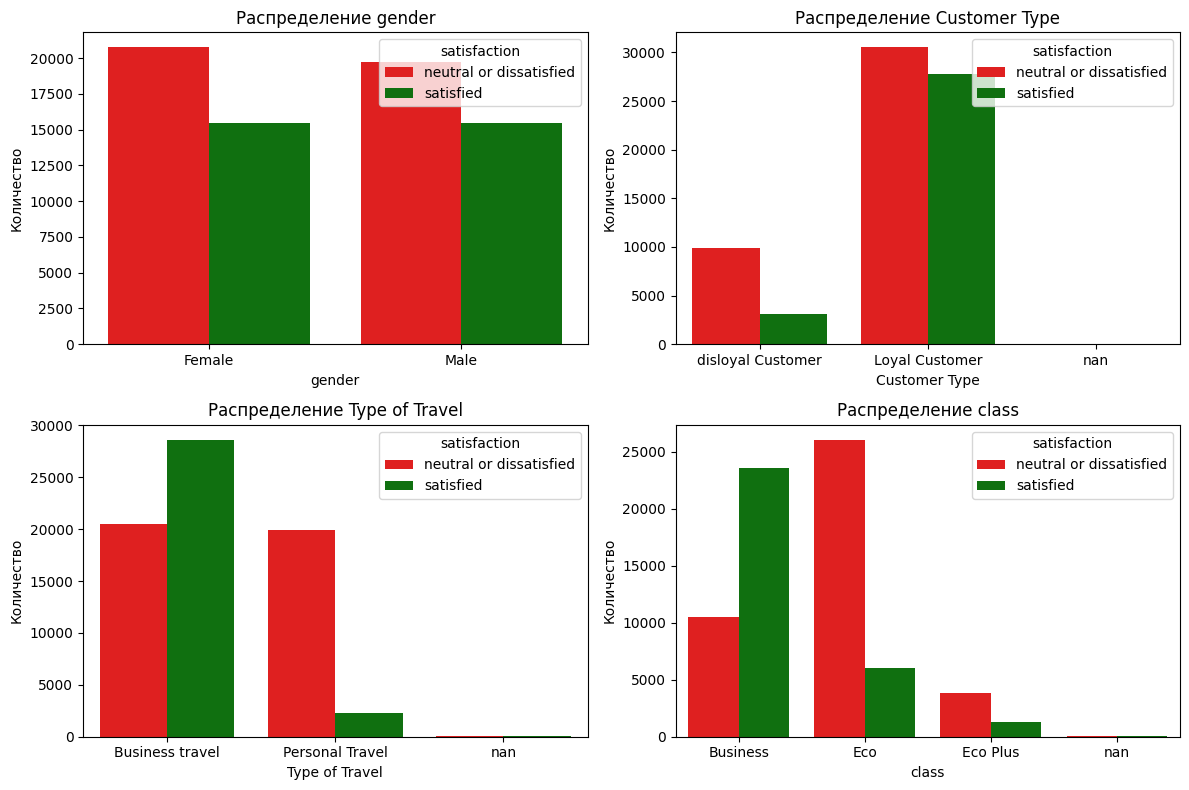

In [39]:
plot_categorical(categorical_cols, X_train, y_train)

/var/folders/hd/xbpxzxnn33d2wx_tj5j02_s40000gn/T/ipykernel_90089/4289975081.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='satisfaction', y=col, palette=palette, ax=axes[i,1])
/var/folders/hd/xbpxzxnn33d2wx_tj5j02_s40000gn/T/ipykernel_90089/4289975081.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='satisfaction', y=col, palette=palette, ax=axes[i,1])
/var/folders/hd/xbpxzxnn33d2wx_tj5j02_s40000gn/T/ipykernel_90089/4289975081.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='sat

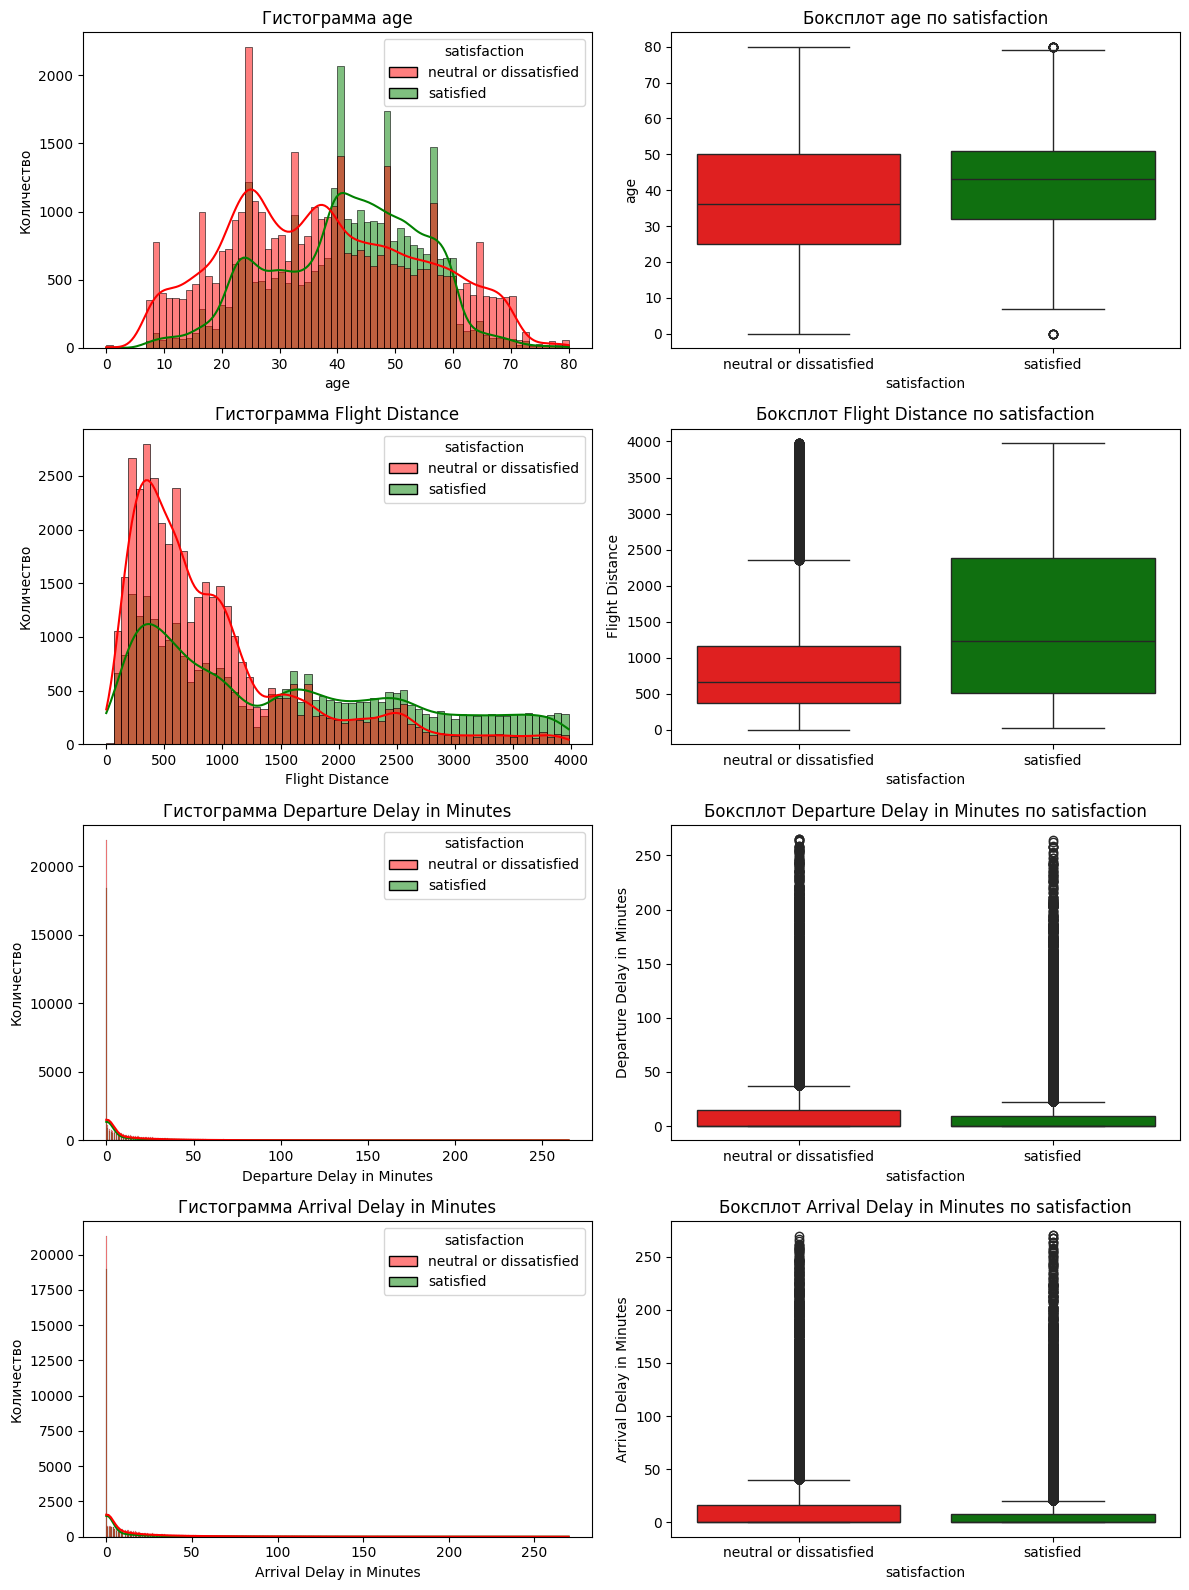

In [40]:
plot_continuous(continuous_cols, X_train, y_train)

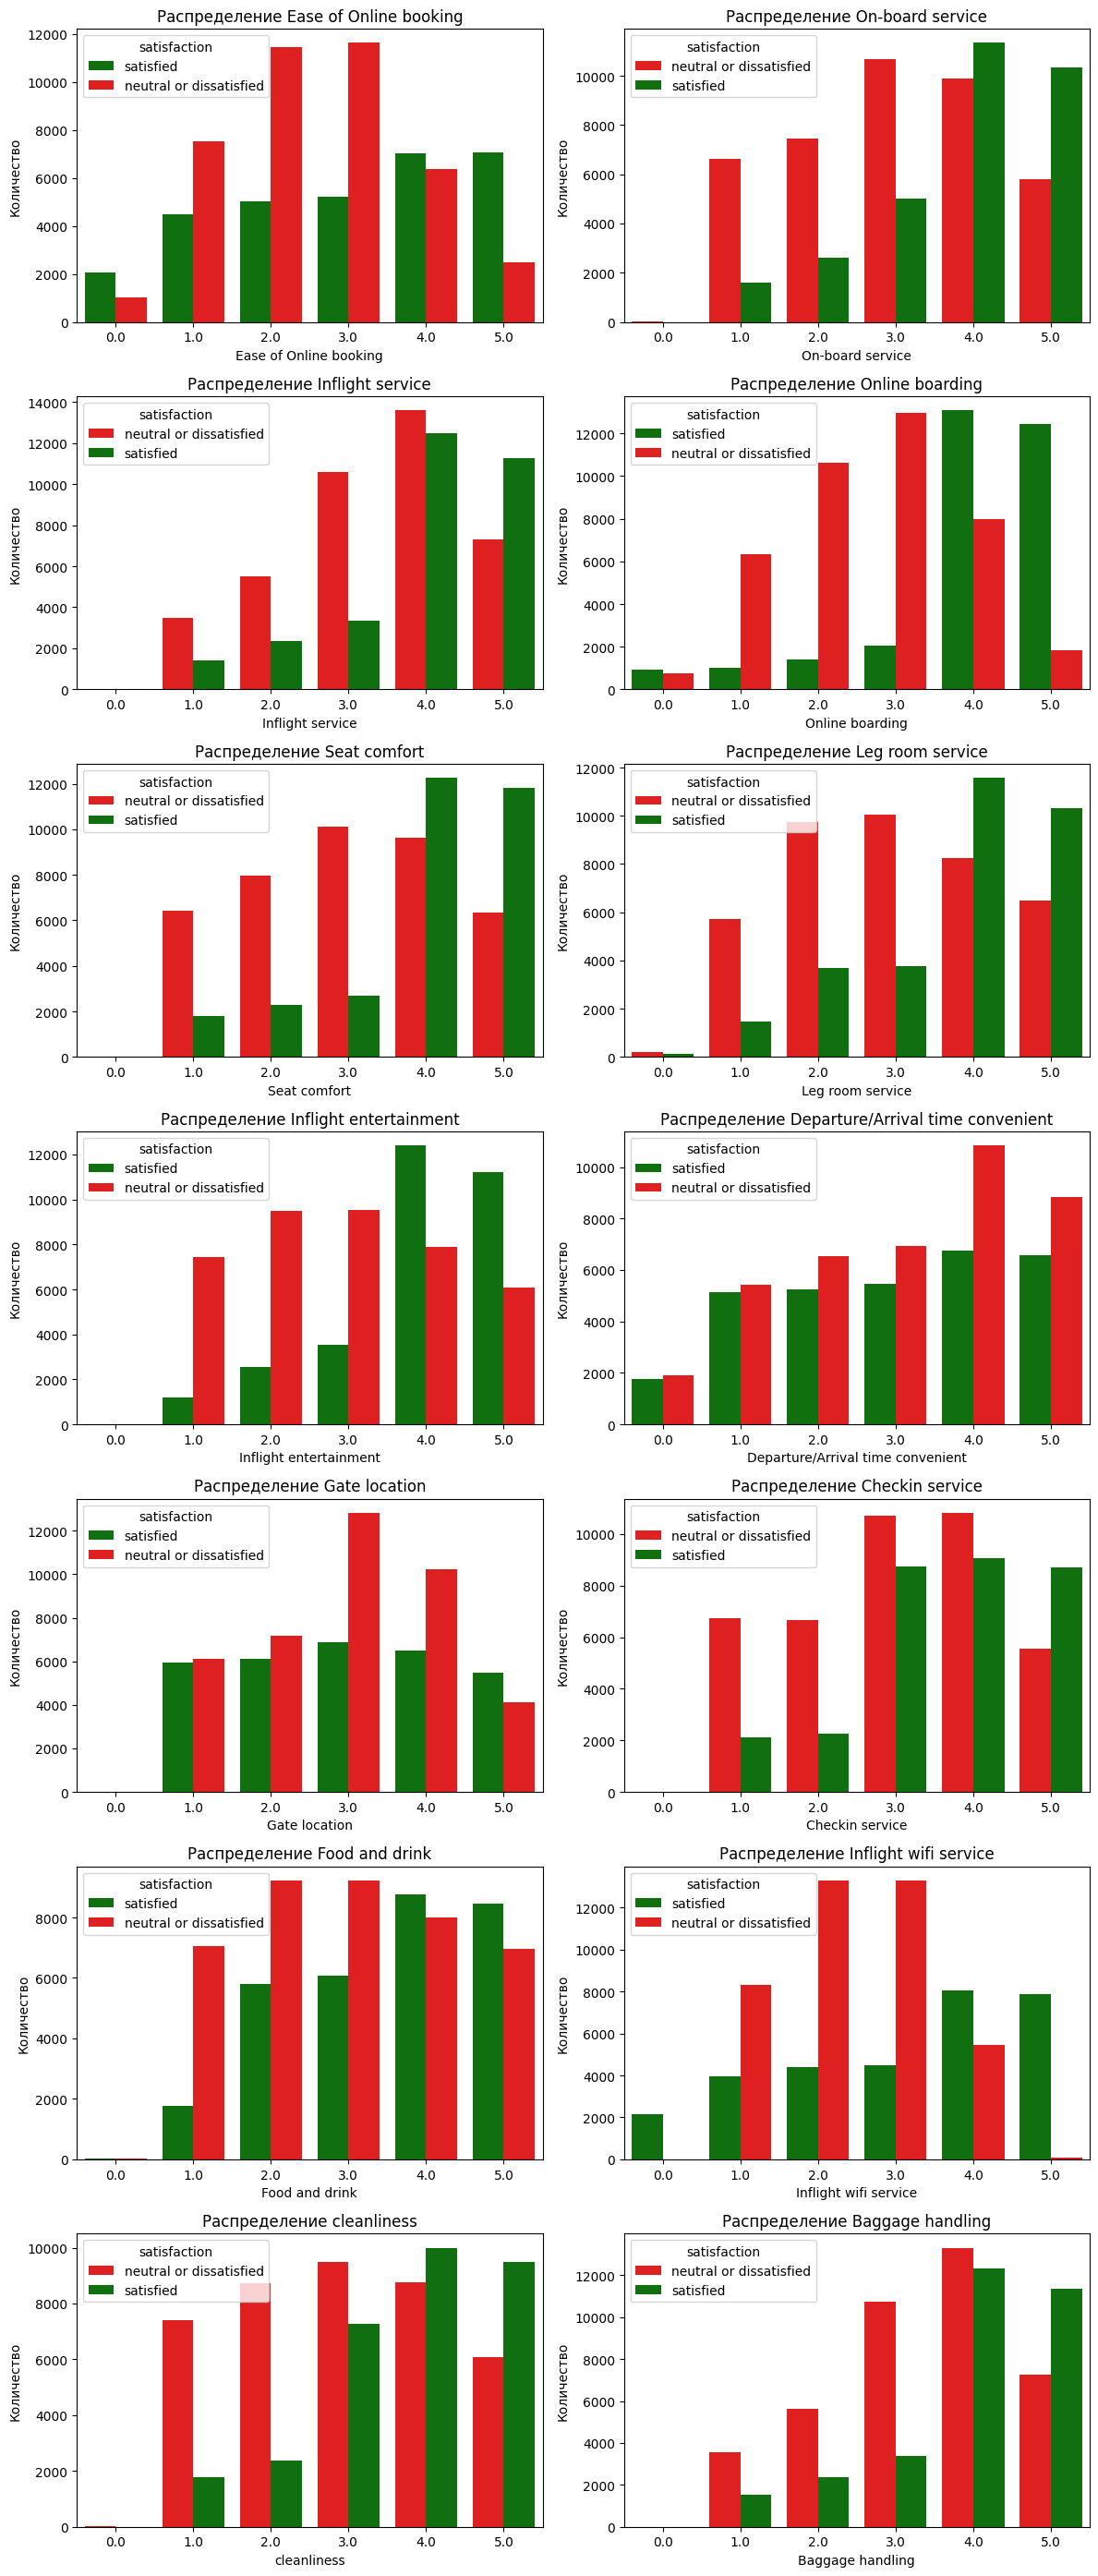

In [41]:
plot_ordinal(ordinal_cols, X_train, y_train)

/var/folders/hd/xbpxzxnn33d2wx_tj5j02_s40000gn/T/ipykernel_90089/455452404.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette=palette)


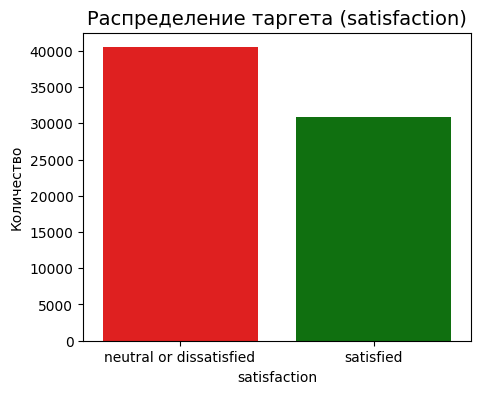

In [42]:
# visualize y_train
palette = {'neutral or dissatisfied':'red', 'satisfied':'green'}

plt.figure(figsize=(5,4))
sns.countplot(x=y_train, palette=palette)
plt.title('Распределение таргета (satisfaction)', fontsize=14)
plt.xlabel('satisfaction')
plt.ylabel('Количество')
plt.show()

### **Задание 8 (0.2 балла)**

Сделайте выводы по построенным графикам.

Не забудьте упомянуть:
* какие признаки распределены неравномерно
* сбалансированы ли классы
* какие распределения имеют континуальные признаки


```
Ваш ответ здесь
```

- Таргет не сбалансирован, недовольных/нейтральных больше чем довольных
- Также на этом этапе я заметила, что у категориальных признаков пустые значения заполнены как 'nan', ниже перезаполню и вызову график еще раз
- Можно отметить по категориальным признакам, что женщины чаще остаются недовольными, нелояльные клиенты чаще остаются НЕ довольными, как и Personal travel тоже чаще недовольны, как и EcoClass - недовольных в разы больше чем довольных 
- Недовольные чаще ставили оценку до 4, а довольные от 4 до 5
- Чем дольше длился полет, тем довольнее были пассажиры 
- Континиусные признаки (кроме возраста) смещены влево, возраст примерно похож на равномерное распределение
- Чем дольше была задержка, тем недовольнее клиент (что логично!)



In [43]:
X_train[categorical_cols] = X_train[categorical_cols].replace('nan', np.nan)
X_val[categorical_cols] = X_val[categorical_cols].replace('nan', np.nan)

cat_imputer = SimpleImputer(strategy='most_frequent')

X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_val[categorical_cols] = cat_imputer.transform(X_val[categorical_cols])

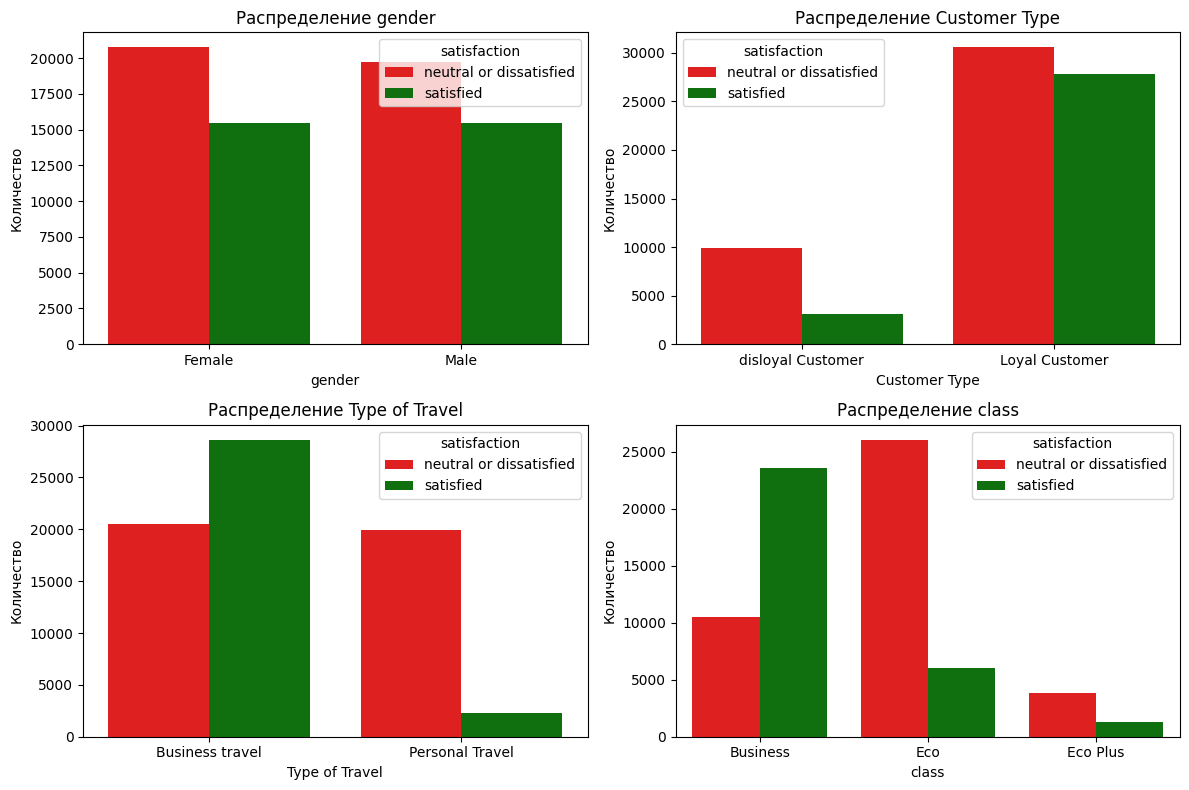

In [44]:
plot_categorical(categorical_cols, X_train, y_train)

### **Бонус (0.1 балла)**
По графикам (каким, решите сами) оцените, похожи ли оказались распределения признаков при разбиении на трейн, валидацию и тест.

как я поняла, нужно сделать те же графики только для трех датасетов? 

In [45]:
# Ваш код ниже
palette_split = {
    'train': 'blue',
    'validation': 'orange',
    'test': 'green'
}

def plot_categorical_compare(cols, train_df, val_df, test_df):
    n = len(cols)
    fig, axes = plt.subplots((n + 1)//2, 2, figsize=(14, 4*((n + 1)//2)))
    axes = axes.flatten()
    
    for i, col in enumerate(cols):
        combined = pd.concat([
            train_df[[col]].assign(dataset='train'),
            val_df[[col]].assign(dataset='validation'),
            test_df[[col]].assign(dataset='test')
        ])
        sns.countplot(x=col, hue='dataset', data=combined, ax=axes[i], palette=palette_split)
        axes[i].set_title(f'Категориальный признак: {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Количество')
        axes[i].legend(title='Dataset')
    
    plt.tight_layout()
    plt.show()


def plot_ordinal_compare(cols, train_df, val_df, test_df):
    n = len(cols)
    fig, axes = plt.subplots((n + 1)//2, 2, figsize=(14, 4*((n + 1)//2)))
    axes = axes.flatten()
    
    for i, col in enumerate(cols):
        combined = pd.concat([
            train_df[[col]].assign(dataset='train'),
            val_df[[col]].assign(dataset='validation'),
            test_df[[col]].assign(dataset='test')
        ])
        sns.countplot(x=col, hue='dataset', data=combined, ax=axes[i], palette=palette_split)
        axes[i].set_title(f'Порядковый признак: {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Количество')
        axes[i].legend(title='Dataset')
    
    plt.tight_layout()
    plt.show()

def plot_continuous_compare(cols, train_df, val_df, test_df):
    n = len(cols)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4*n)) 
    
    for i, col in enumerate(cols):
        combined = pd.concat([
            train_df[[col]].assign(dataset='train'),
            val_df[[col]].assign(dataset='validation'),
            test_df[[col]].assign(dataset='test')
        ])

        sns.histplot(data=combined, x=col, hue='dataset', palette=palette_split, kde=True, ax=axes[i,0])
        axes[i,0].set_title(f'Гистограмма {col}')
        axes[i,0].set_xlabel(col)
        axes[i,0].set_ylabel('Количество')

        sns.boxplot(data=combined, x='dataset', y=col, palette=palette_split, ax=axes[i,1])
        axes[i,1].set_title(f'Боксплот {col} по выборкам')
        axes[i,1].set_xlabel('Dataset')
        axes[i,1].set_ylabel(col)
    
    plt.tight_layout()
    plt.show()

def plot_target_compare(y_train, y_val, y_test):
    df = pd.DataFrame({
        'satisfaction': pd.concat([y_train, y_val, y_test], axis=0),
        'dataset': ['train']*len(y_train) + ['validation']*len(y_val) + ['test']*len(y_test)
    })
    
    plt.figure(figsize=(8,5))
    sns.countplot(x='satisfaction', hue='dataset', data=df, palette=palette_split)
    plt.title('Распределение таргета по выборкам')
    plt.xlabel('satisfaction')
    plt.ylabel('Количество')
    plt.legend(title='Dataset')
    plt.show()


In [46]:
#у нас пока нет тестового дата сета, делаю
df_test = df[df.satisfaction == '-']
X_test = df_test.drop('satisfaction', axis=1)
y_test = df_test.satisfaction

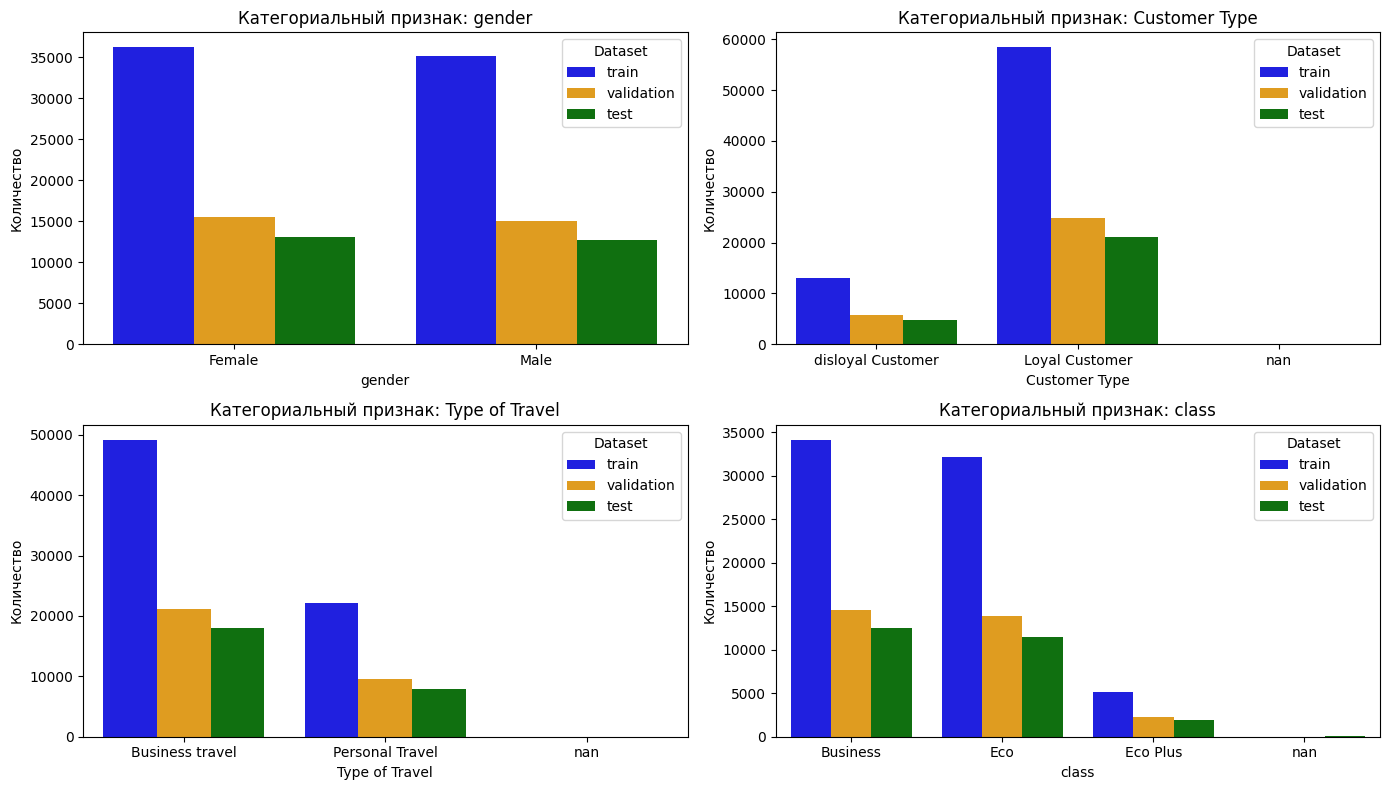

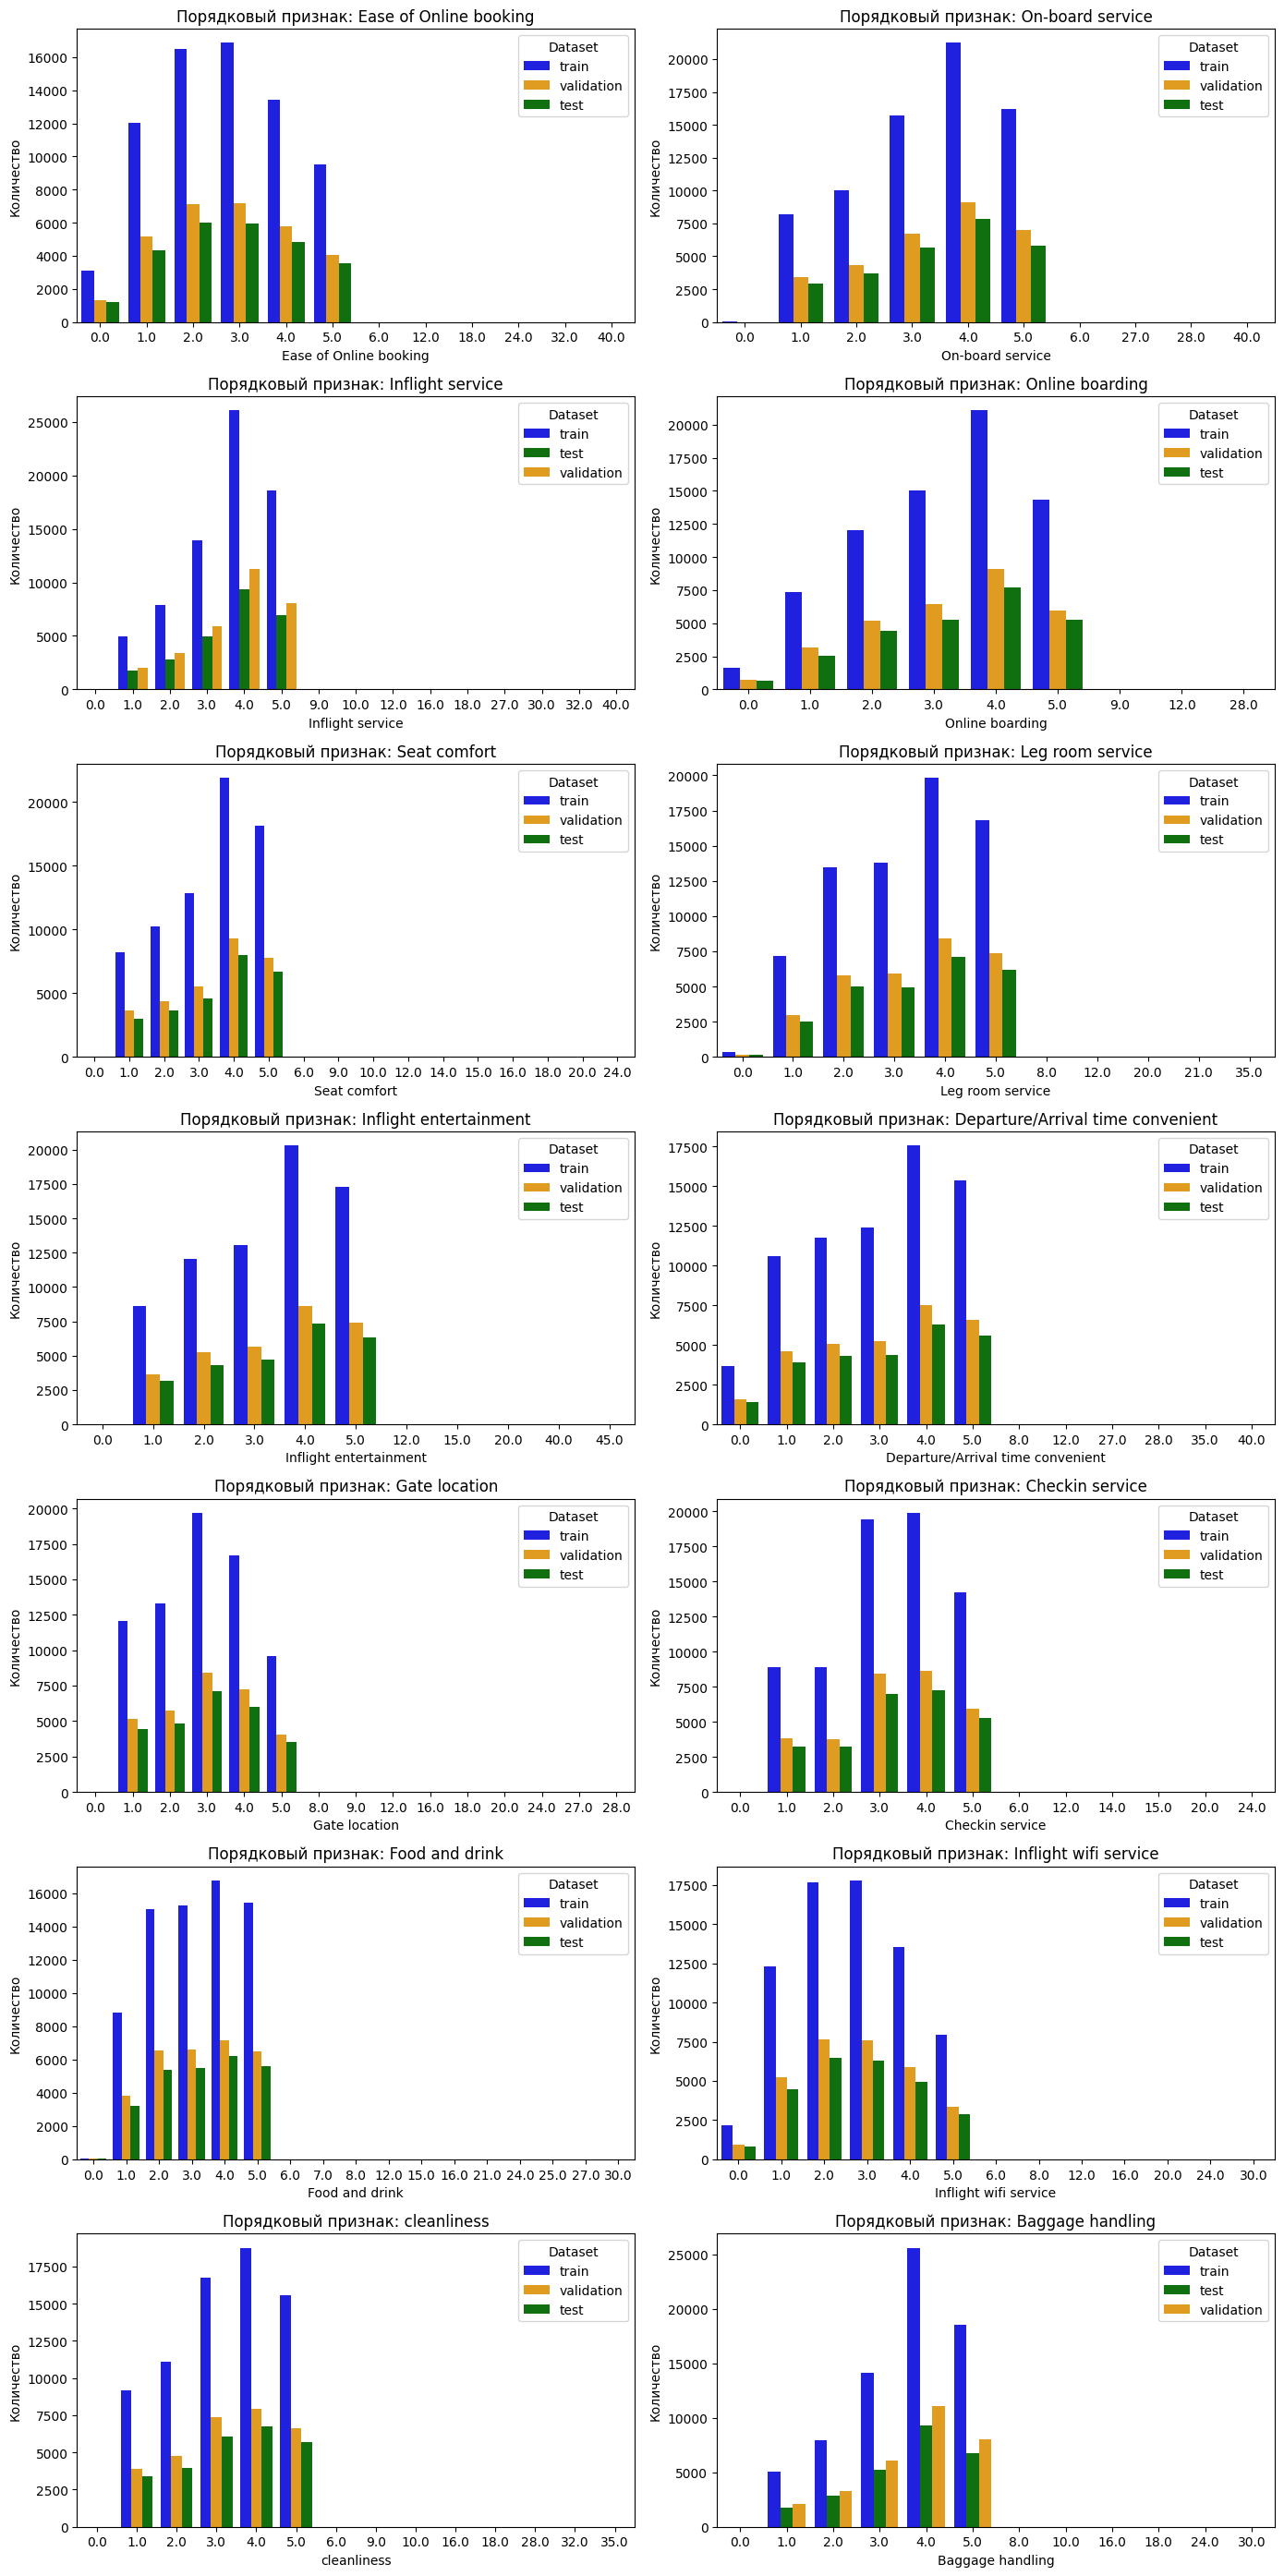

/var/folders/hd/xbpxzxnn33d2wx_tj5j02_s40000gn/T/ipykernel_90089/1954973518.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x='dataset', y=col, palette=palette_split, ax=axes[i,1])
/var/folders/hd/xbpxzxnn33d2wx_tj5j02_s40000gn/T/ipykernel_90089/1954973518.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x='dataset', y=col, palette=palette_split, ax=axes[i,1])
/var/folders/hd/xbpxzxnn33d2wx_tj5j02_s40000gn/T/ipykernel_90089/1954973518.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x

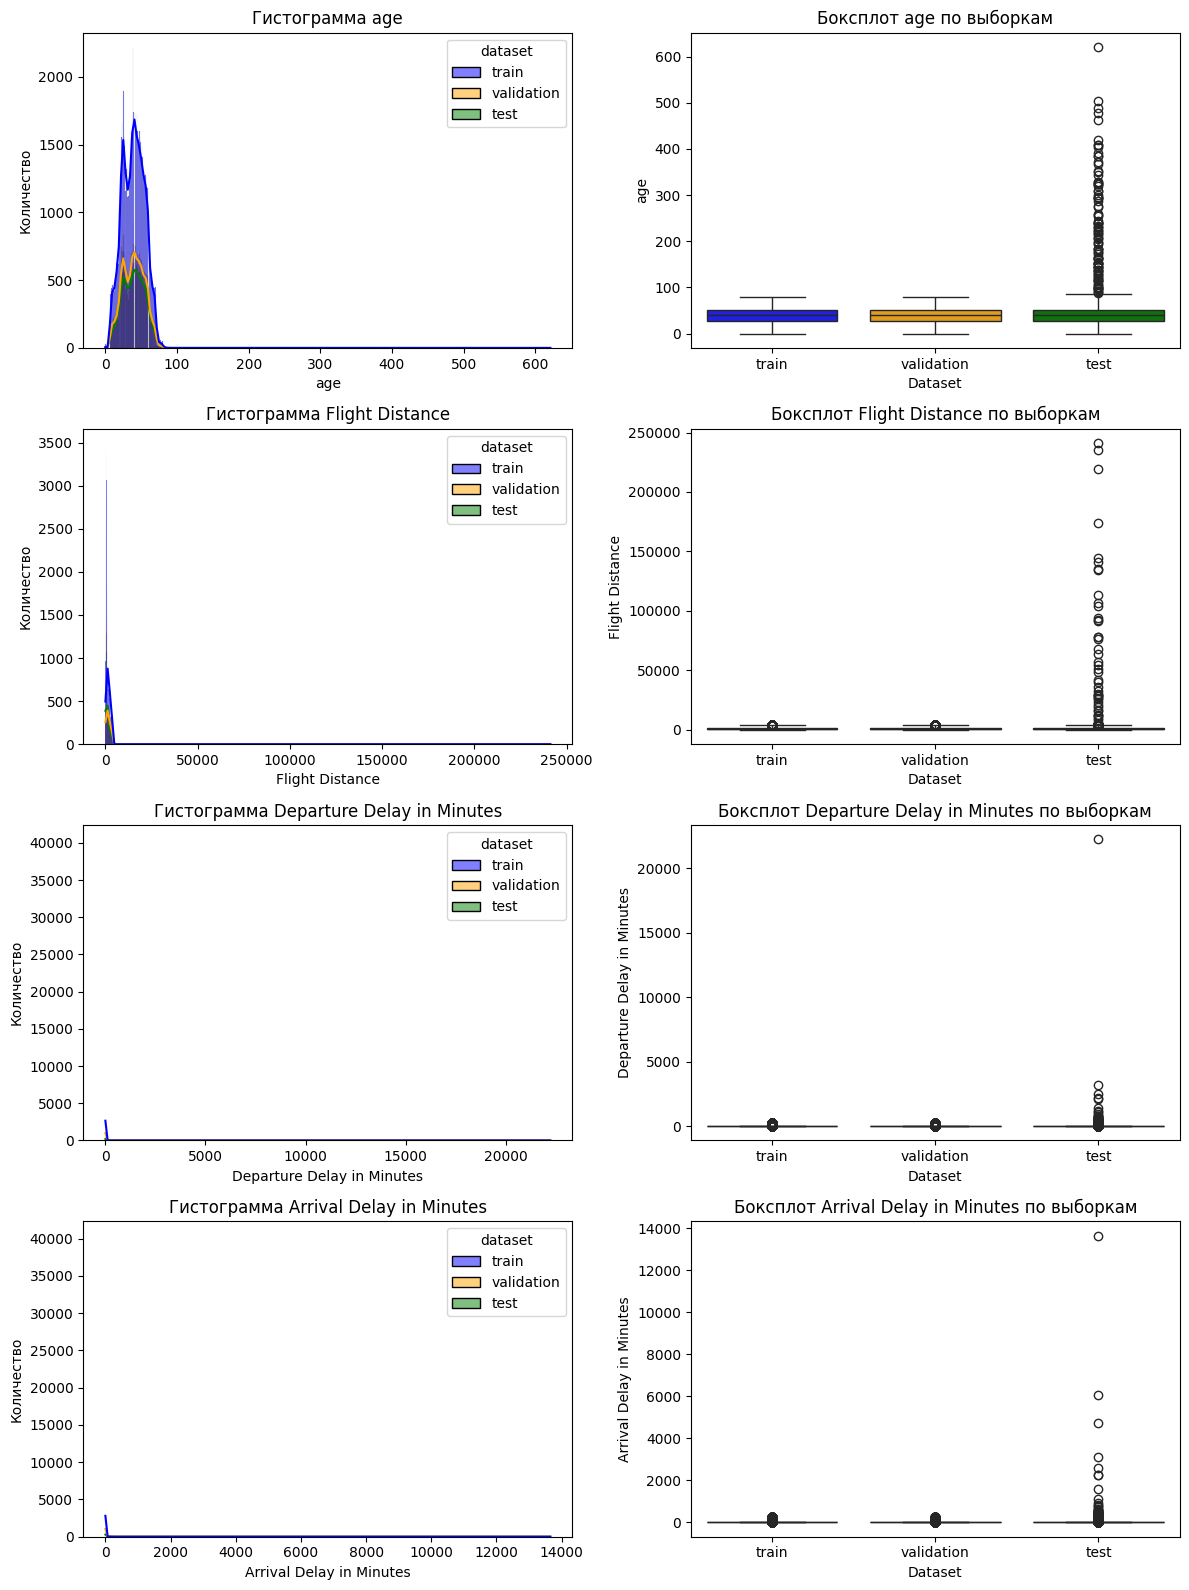

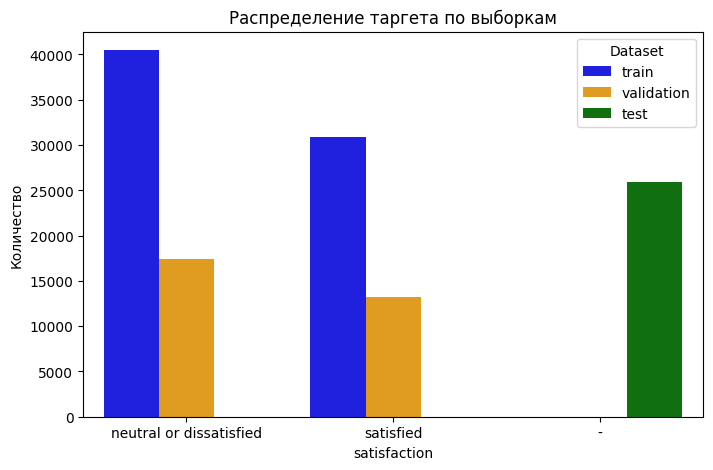

In [47]:
plot_categorical_compare(categorical_cols, X_train, X_val, X_test)
plot_ordinal_compare(ordinal_cols, X_train, X_val, X_test)
plot_continuous_compare(continuous_cols, X_train, X_val, X_test)
plot_target_compare(y_train, y_val, y_test)

Распределения у нас схожи между тренировочными, валидационными и тестовыми датасетами + также видно, что в тестовом остались выбросы, а в тренировочной и валидационной их убрали.

### **Задание 9 (0.25 балла)**

- Замените признаки "Departure Delay in Minutes" и "Arrival Delay in Minutes" на их логарифмы.
- Заново постройте графики континуальных признаков и сделайте вывод по преобразованию

Некоторые признаки полезно рассматривать в логарифмической шкале. Зачем? Она помогает анализировать большие диапазоны изменений (посмотрите на график логарифма).


In [48]:
# Ваш код ниже

log_cols = ['Departure Delay in Minutes', 'Arrival Delay in Minutes']

for col in log_cols:
    X_train[col] = np.log1p(X_train[col])

for col in log_cols:
    X_val[col] = np.log1p(X_val[col])


Построение

/var/folders/hd/xbpxzxnn33d2wx_tj5j02_s40000gn/T/ipykernel_90089/4289975081.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='satisfaction', y=col, palette=palette, ax=axes[i,1])
/var/folders/hd/xbpxzxnn33d2wx_tj5j02_s40000gn/T/ipykernel_90089/4289975081.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='satisfaction', y=col, palette=palette, ax=axes[i,1])
/var/folders/hd/xbpxzxnn33d2wx_tj5j02_s40000gn/T/ipykernel_90089/4289975081.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='sat

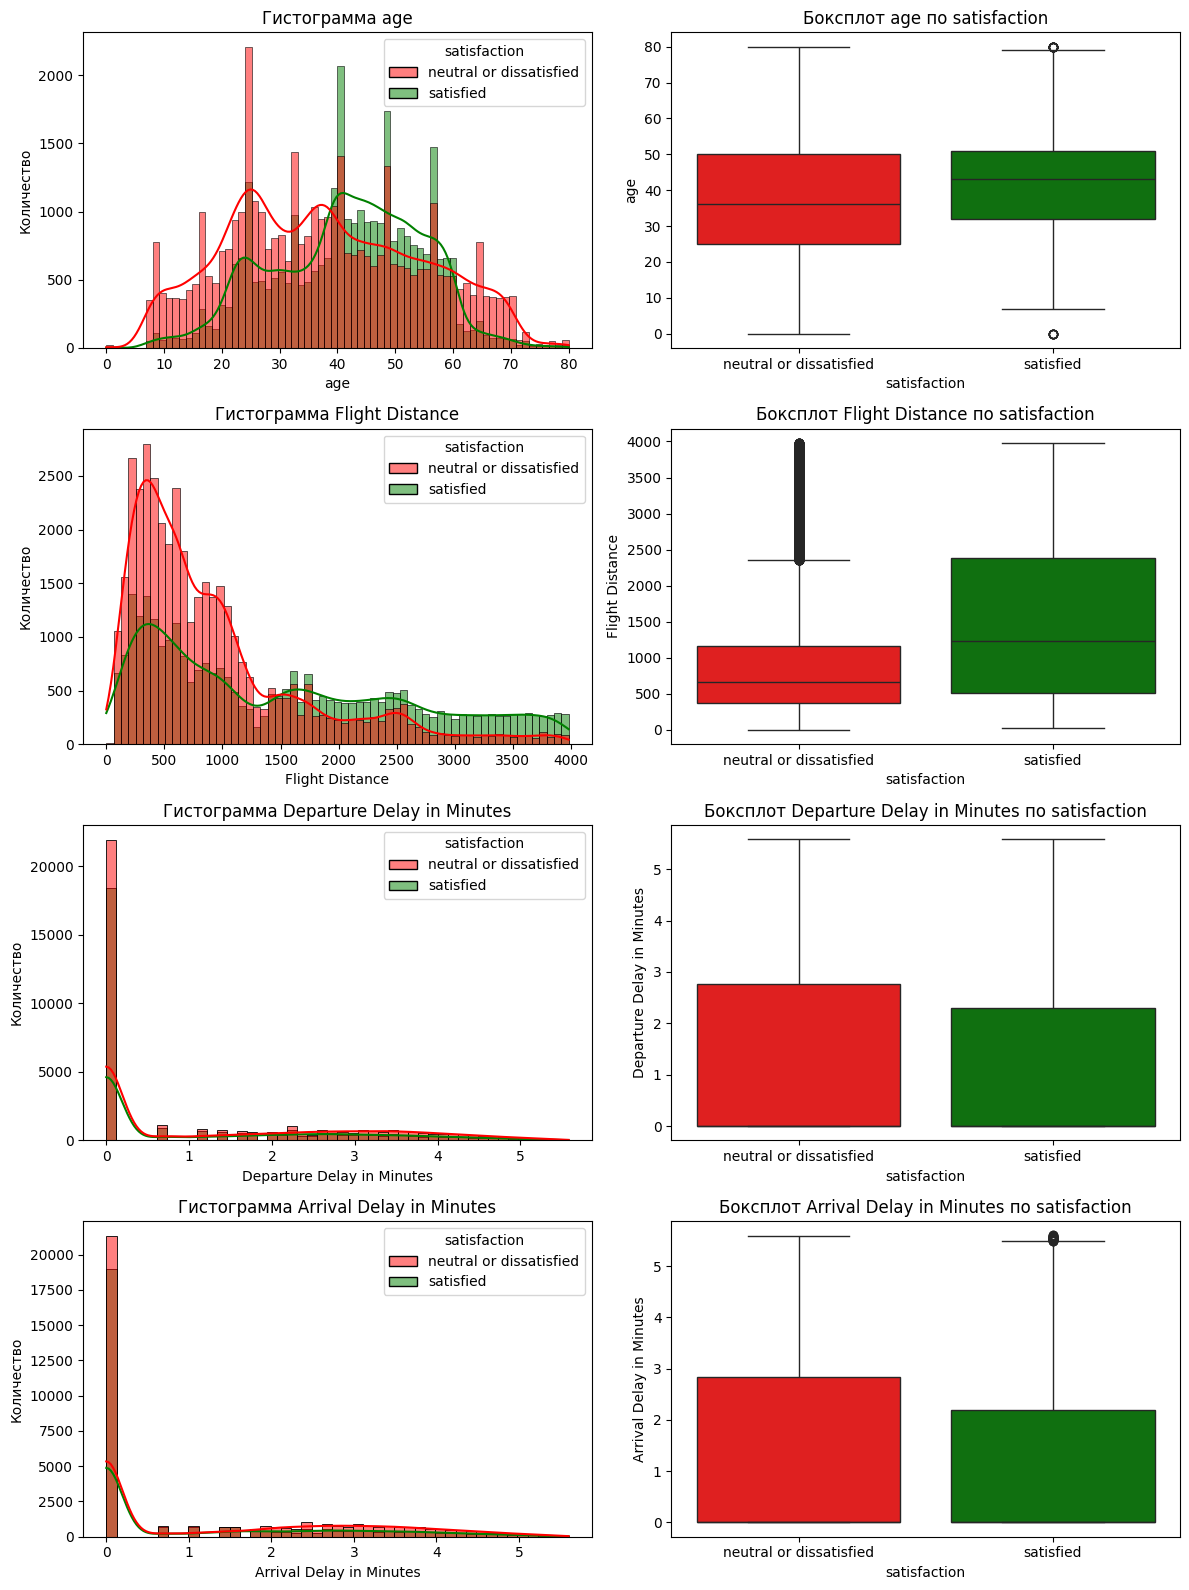

In [49]:
plot_continuous(continuous_cols, X_train, y_train)

Да, теперь построение лучше видно

### **Задание 10 (0.25 балла)**

Выше вы рассмотрели `boxplot` и графики распределений. Но иногда полезным оказывается `scatterplot, (pairplot)` в seabron. Проверьте, что покажет этот график в нашей задаче.

- Отобразите попарное распределение континуальных (по договоренности) признаков. Покрасьте точки на pairplot'е в соответствии с их классом.

**Примечание:**
Наблюдений много, так что отрисовка графика вполне может занять несколько минут

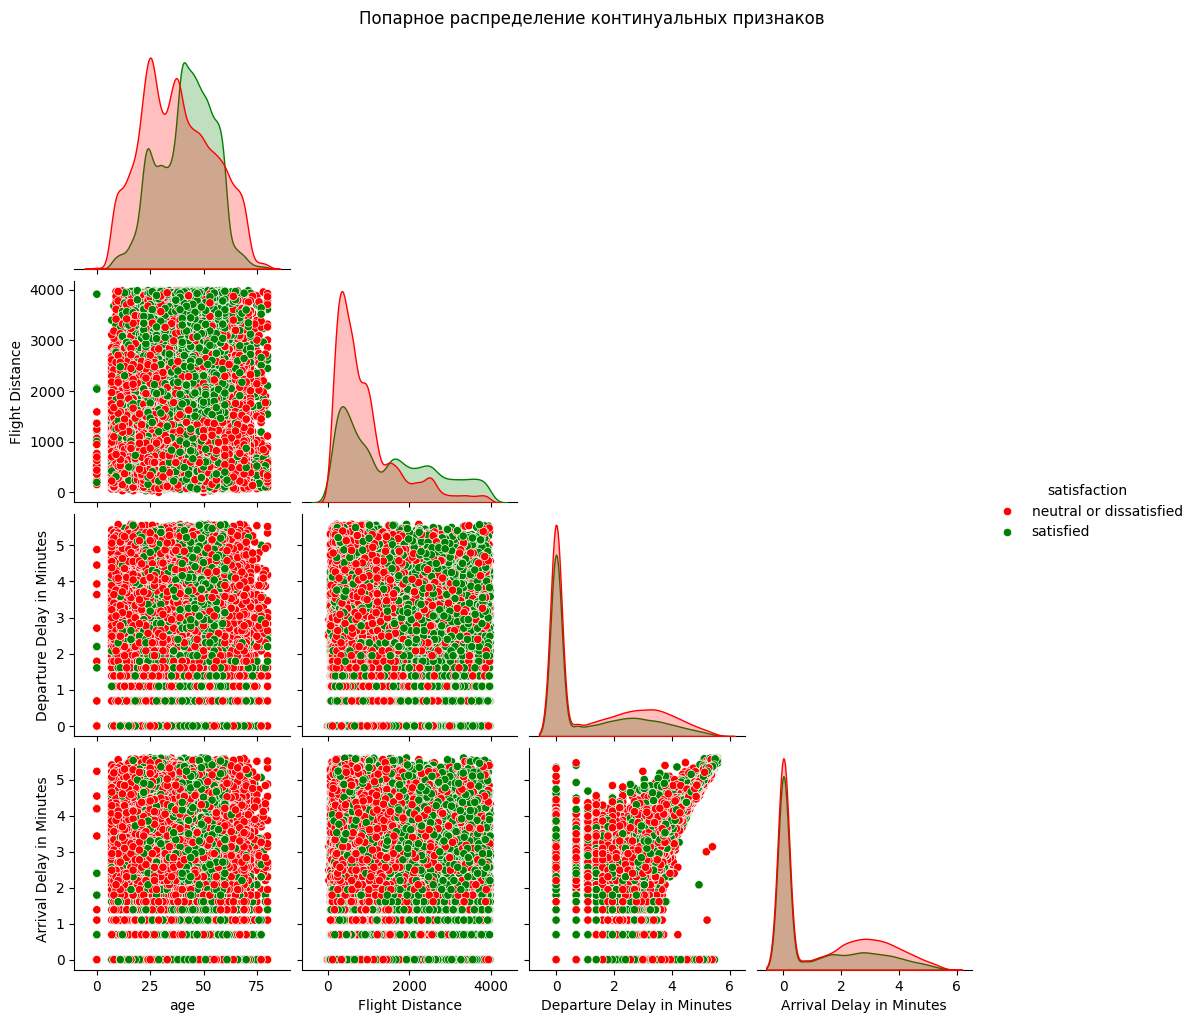

In [50]:
plot_data = X_train[continuous_cols].join(y_train)
palette = {'neutral or dissatisfied':'red', 'satisfied':'green'}
sns.pairplot(plot_data, 
             hue='satisfaction', 
             palette=palette,
             diag_kind='kde',  
             corner=True)   
plt.suptitle('Попарное распределение континуальных признаков', y=1.02)
plt.show()

# **Часть 2. Decision Tree (3 балла)**

### **Задание 11 (0.4 балла)**

Предобработайте данные для алгоритма.
- Закодируйте таргет таким образом, чтоб 'satisfied' перешел в 1, а остальные значения в 0;
- Закодируйте категориальные признаки методом OHE;

In [51]:
# Ваш код ниже
y_train = y_train.apply(lambda x: 1 if x == 'satisfied' else 0)
y_val = y_val.apply(lambda x: 1 if x == 'satisfied' else 0)

print(y_train.value_counts())
print(y_val.value_counts())

X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, columns=categorical_cols, drop_first=True)

print(f"Новая форма X_train: {X_train_encoded.shape}")
print(f"Новая форма X_val: {X_val_encoded.shape}")

satisfaction
0    40484
1    30911
Name: count, dtype: int64
satisfaction
0    17389
1    13211
Name: count, dtype: int64
Новая форма X_train: (71395, 23)
Новая форма X_val: (30600, 23)


### **Задание 12. (0.1 балла)**

- Обучите дерево решений с параметрами по умолчанию на имеющихся данных.
- Выведите `accuracy_score` для валидационной подвыборки

**Примечание**:

Здесь и далее, где вас просят что-нибудь обучить, выводите **везде** `accuracy_score` для валидационной подвыборки.

In [52]:
# Ваш код ниже
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_encoded, y_train)

y_val_pred = dt.predict(X_val_encoded)

val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Accuracy на валидационной подвыборке: {val_accuracy:.4f}")

Accuracy на валидационной подвыборке: 0.9430


Хороший результат! 

## **Анализ построенной модели**

### **Задание 13. (0.5 балла)**

- Посчитайте bias и variance для построенного дерева. Для этого проще всего вспользоваться функцией `bias_variance_decomp()` из модуля mlxtend. Используйте '0-1_loss'

In [53]:
# Ваш код ниже — дополните его

error_dt, bias_dt, var_dt = bias_variance_decomp(
    dt,        
    X_train_encoded.values, 
    y_train.values, 
    X_val_encoded.values,   
    y_val.values, 
    loss='0-1_loss',        
    random_seed=42
)
error_dt, bias_dt, var_dt

(np.float64(0.061766339869281046),
 np.float64(0.040522875816993466),
 np.float64(0.04599313725490196))

Можно сделать вывод, что у дерева относительно низкий bias, что логично, так как оно гибкое и может хорошо аппроксимировать данные. Что касается варианса, то оно чуть выше байеса — дерево может переобучаться на мелких особенностях выборки, но в целом ошибка небольшая.

### **Задание 14. (0.2 балла)**

Проанализируйте структурные характеристики дерева.
- Какой глубины получилось дерево?
- Сколько в нем листьев?

In [54]:
# Ваш код ниже
depth = dt.tree_.max_depth
print(f"Глубина дерева: {depth}")

n_leaves = dt.tree_.n_leaves
print(f"Количество листьев: {n_leaves}")

Глубина дерева: 31
Количество листьев: 2099


Дерево довольно глубокое, возможно переобучение, модель запоминает все и на тестовых (новых) данных может дать плохой результат

### **Задание 15. (0.3 балла)**

Проанализируйте важность признаков, вычисляемую в дереве по построению.

- Выведите на экран barplot, демонстрирующий оценки важности признаков.
- Укажите, какие признаки оказались наиболее информативными?

/var/folders/hd/xbpxzxnn33d2wx_tj5j02_s40000gn/T/ipykernel_90089/2550572407.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='Spectral')


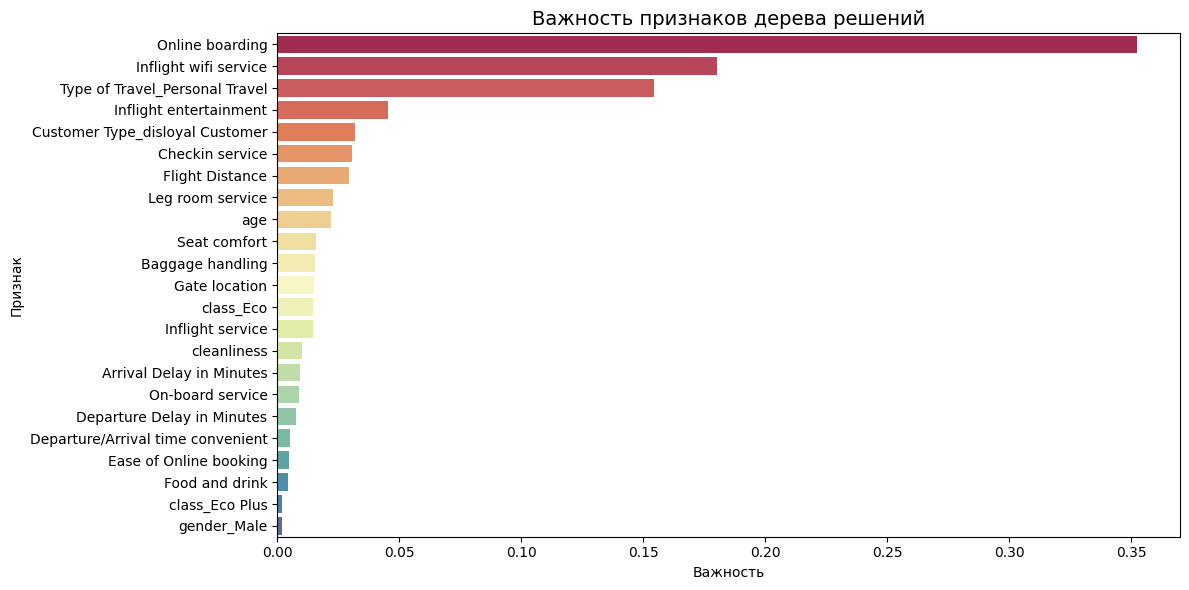

In [55]:
feature_importances = pd.Series(dt.feature_importances_, index=X_train_encoded.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='Spectral')
plt.title('Важность признаков дерева решений', fontsize=14)
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()


`Ваш ответ здесь.`  

Топ три важных признака: 
1. Online Boarding 
2. Inflight wifi service
3. Type of Travel_Presonal Travel 

Можно отметить, что первые два связаны с современными технологиями, люди считают это важным

### **Задание 16. (0.1 балла)**

- Постройте дерево глубины 5, используя только 2 наиболее информативных признака для предыдущего построенного дерева.

In [56]:
# Ваш код здесь
top_features = ['Online boarding', 'Inflight wifi service']

X_train_top2 = X_train_encoded[top_features]
X_val_top2 = X_val_encoded[top_features]

dt_top2 = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_top2.fit(X_train_top2, y_train)

y_val_pred = dt_top2.predict(X_val_top2)

val_acc_top2 = accuracy_score(y_val, y_val_pred)
print(f"Accuracy на валидационной выборке из двух наиболее важных признаков: {val_acc_top2:.4f}")

Accuracy на валидационной выборке из двух наиболее важных признаков: 0.8248


Метрика упала

### **Задание 17. (0.15 балла)**

- С помощью graphviz визуализируйте получившееся новое дерево решений. Почему предикаты в нем не целые, а кратны 1/2?

У меня мак и не получается установить эту штуку... 

In [57]:
!which dot

dot not found


In [58]:
import os
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"

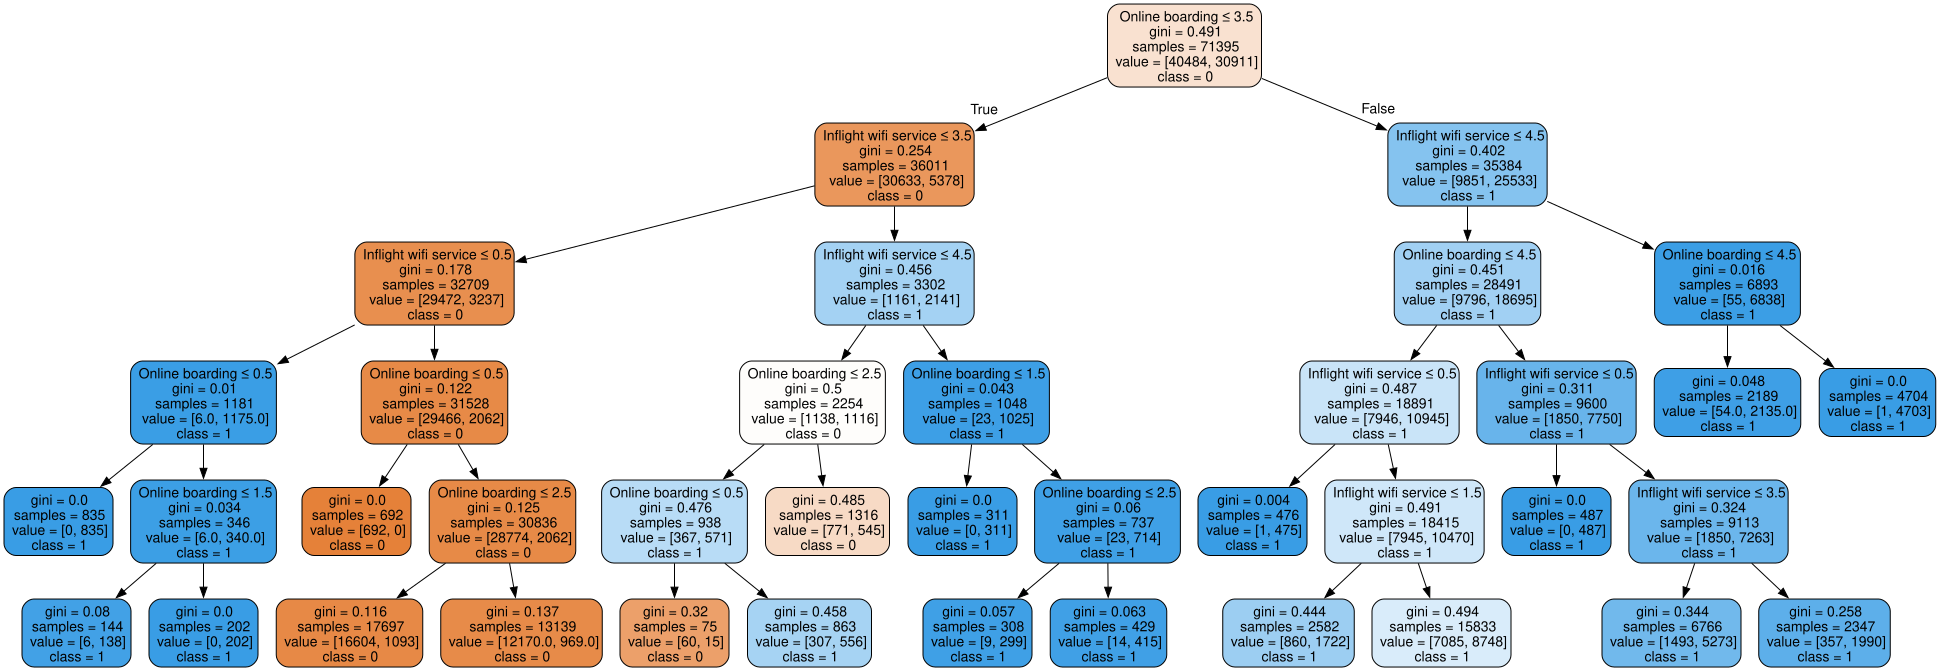

In [59]:
dot_data = export_graphviz(
    dt_top2, 
    out_file=None, 
    feature_names=top_features, 
    class_names=['0', '1'],
    filled=True, 
    rounded=True,
    special_characters=True
)

graph = Source(dot_data)
graph.render("tree_top2", format="png", cleanup=True)
graph

`Ваш ответ здесь. `

*Гуглить — можно, но помните о культуре цитирования.*

Если бы гугл помог в этом вопросе... Ну может это как-то связано с тем, что в этом случае у нас варианты только [0, 1, 2, 3, 4, 5] (дискретные) и чтобы отделить, например, 3 и 4 предикат делает '3.5<=', то есть влево отправляется все что 3 и ниже, а вправо 4 и больше 

### **Задание 18. (0.25 балла)**

- Теперь отобразите его функцией `plot_tree()` из sklearn.
- Проанализируйте — ссимметричным ли получилось дерево? И хорошо ли это, или нет?

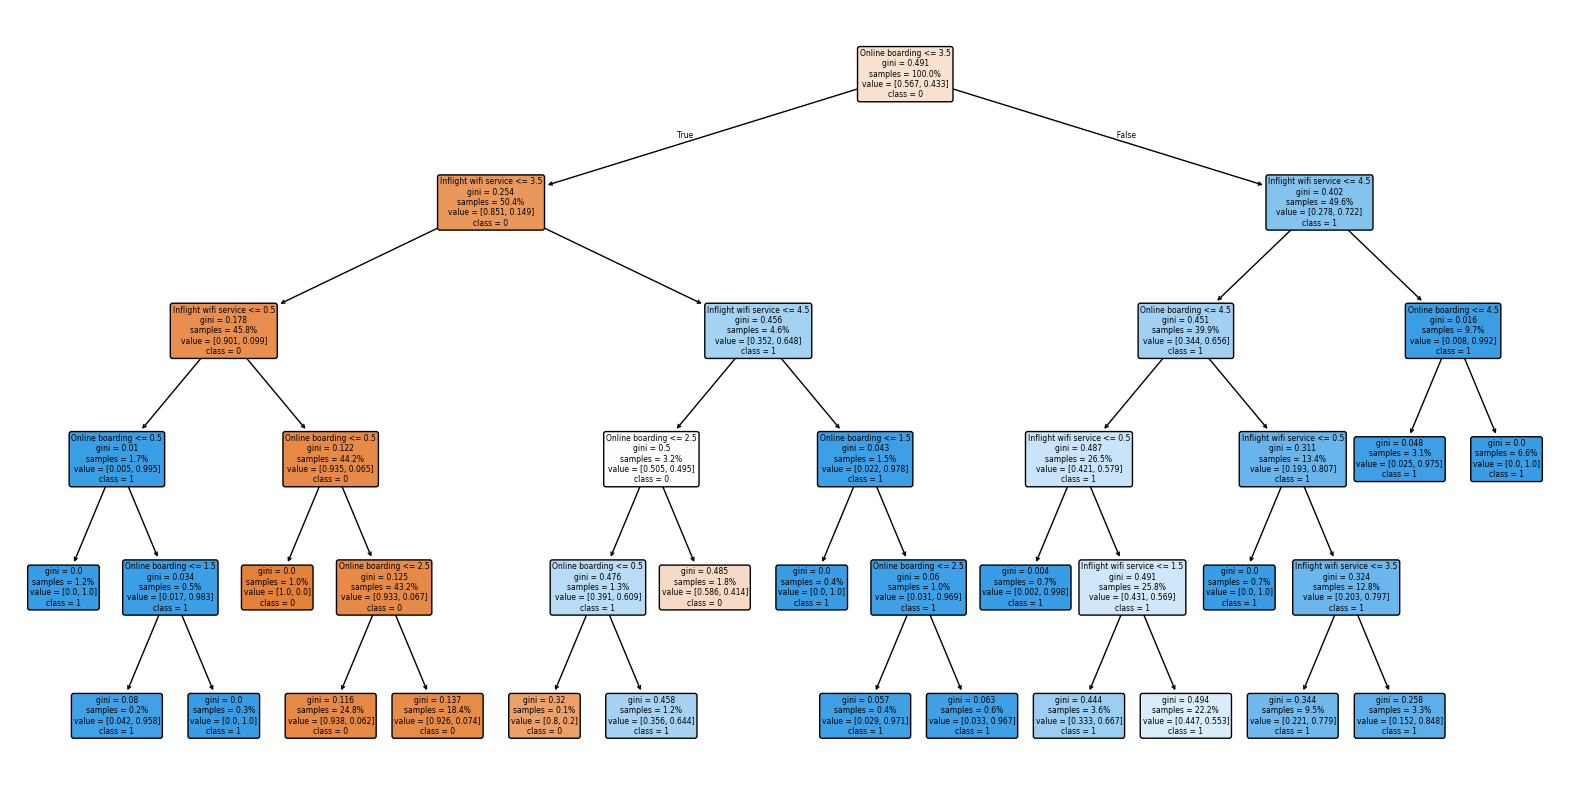

In [60]:
# Ваш код здесь

plt.figure(figsize=(20, 10))  # подбираем размер для читаемости
plot_tree(
    dt_top2,
    feature_names=top_features,
    class_names=['0', '1'],
    filled=True,
    rounded=True,
    proportion=True
)
plt.show()


Мне кажется дерево получилось не симметричным, после первого разделения у левой части больше разбиений. Хорошо это или нет? Не знаю, но самое главное, чтобы дерево сильно глубоко не уходило и не переобучалось

### **Задание 19. (0.5 балла)**

- Используя функцию `plot_decision_regions()` из `mlxtend`, отобразите разделяющую поверхность получившегося дерева. Отметьте на графике только первые 100 объектов обучающей выборки

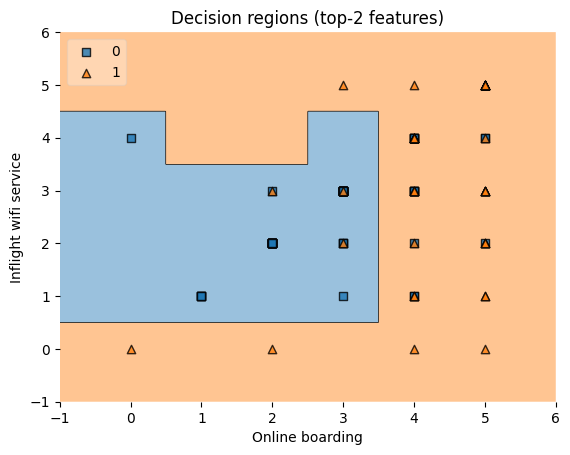

In [61]:
plot_decision_regions(
    X_train_top2[:100].values,
    y_train[:100].values,
    clf=dt_top2,
    legend=2
)

plt.xlabel(top_features[0])
plt.ylabel(top_features[1])
plt.title("Decision regions (top-2 features)")
plt.show()

Можно отметить, что в некоторых случаях квадратики наслаиваются на треугольники, потому что тут дискретные значения всего лишь от 1 до 5

### **Деревья решений. Теоретическая вставка**

Из лекций вам должно быть известно, что деревья решений неустойчивы даже к небольшим изменениям в обучающей выборке. Попробуем показать это!

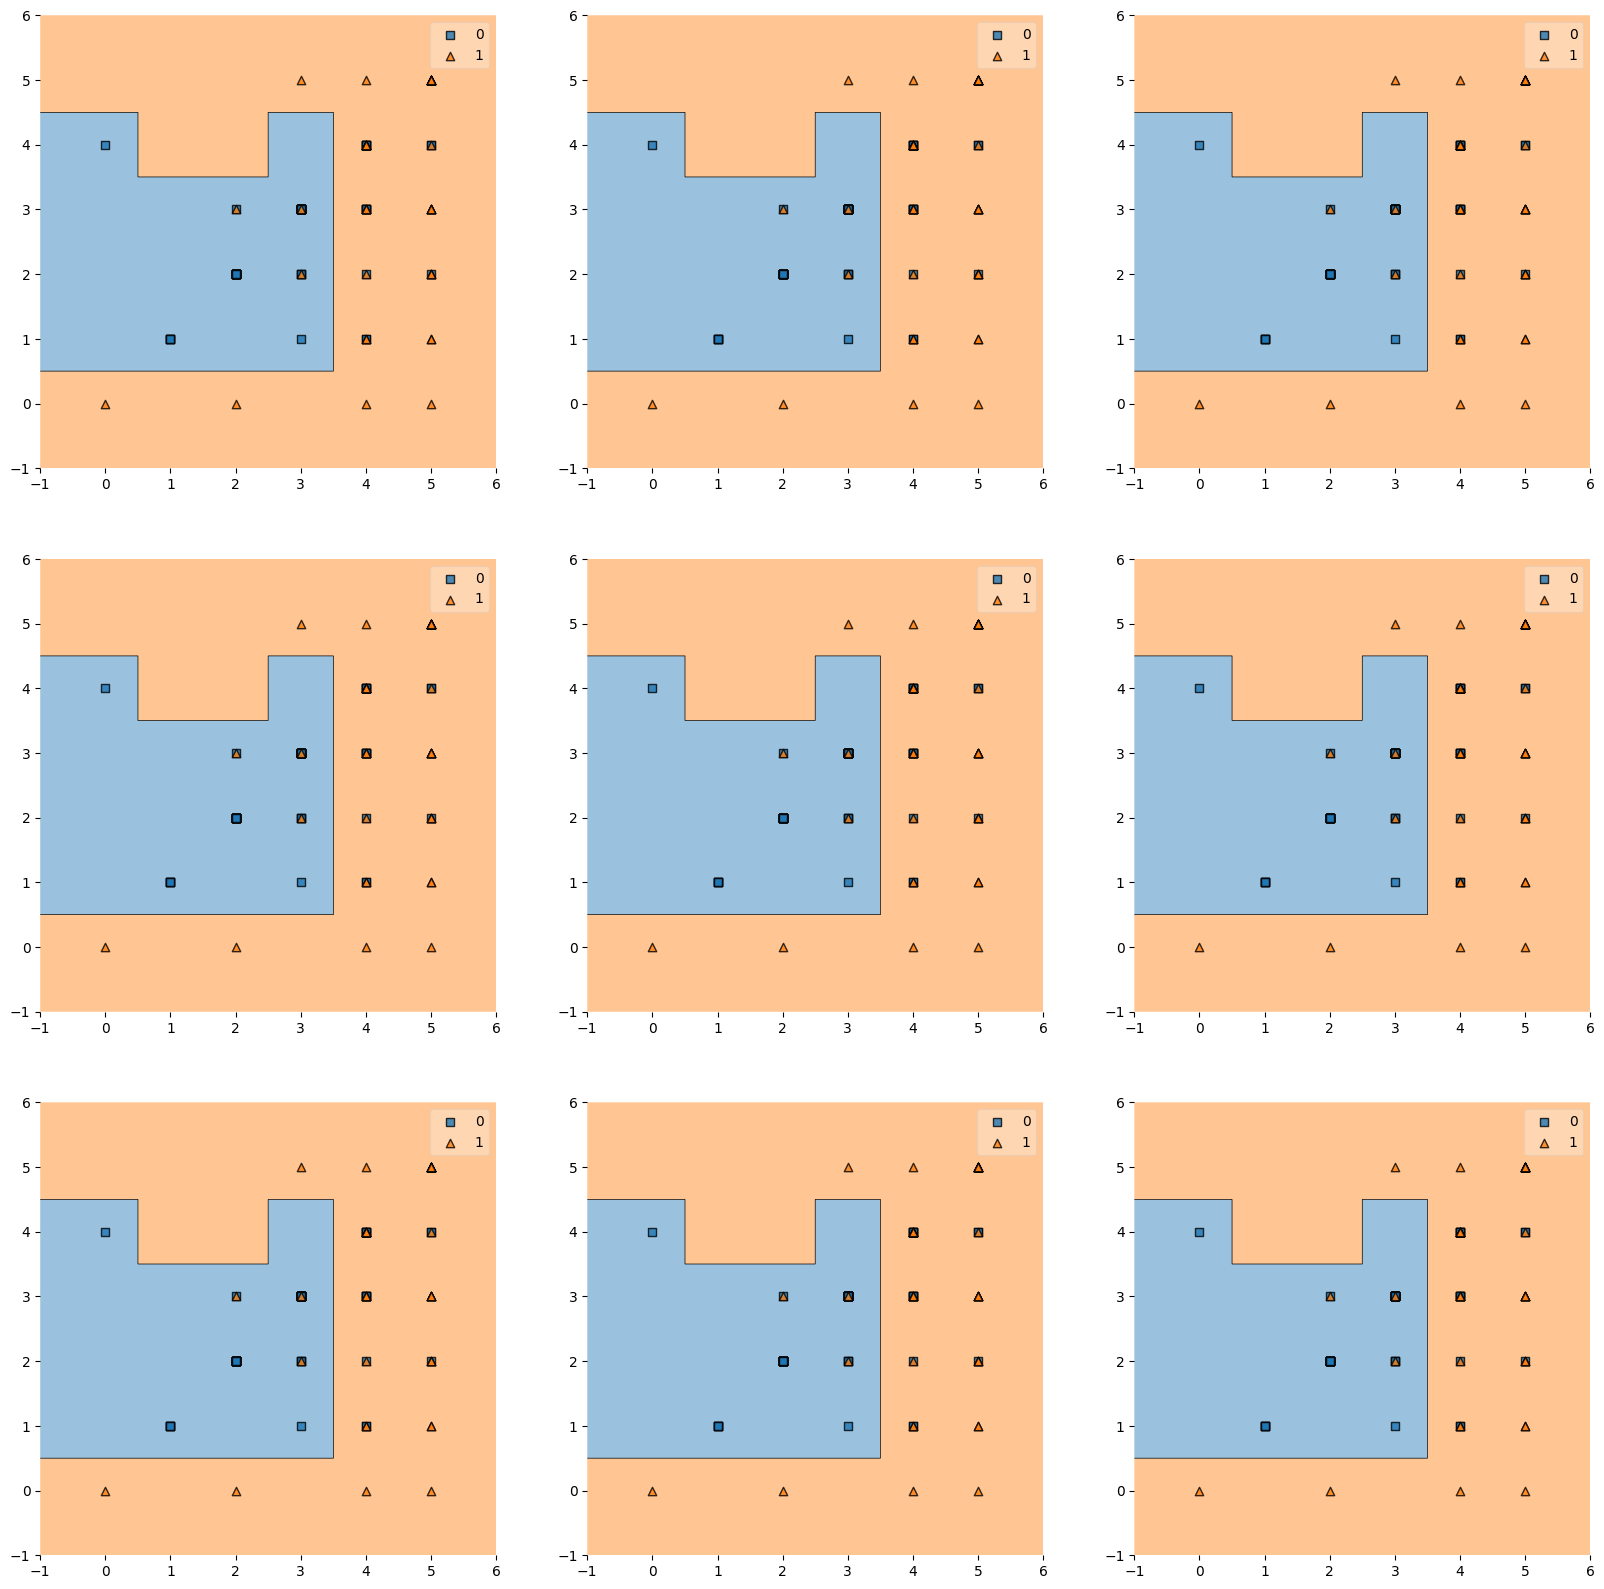

In [62]:
# замените X_train_example на вашу переменную

fig, ax = plt.subplots(3, 3, figsize=(20, 20))

for row in range(3):
    for col in range(3):
        inds = np.random.choice(X_train_top2.index, size=X_train_top2.shape[0] - 1000, replace=False) # нагляднее брать не на 1к, а на 5к меньше объектов, а то почти не изменяется разделяющая поверхность

        tree_exp = DecisionTreeClassifier(max_depth=5, random_state=42)
        tree_exp.fit(X_train_top2.loc[inds, :], y_train[inds])

        plot_decision_regions(clf=tree_exp, X=np.array(X_train_top2.iloc[:100, :]), y=np.array(y_train[:100]), ax=ax[row][col])

**Смотрите как двигается гранится, а ведь мы убирали из трейна (а в нем ~80к наблюдений) всего по тысяче случайных объектов!**

Помимо своей неусточивости деревья решений "славны" ещё и склонностью к переобучению. Посмотрим, можно ли увидеть это свойство на имеющихся у нас данных. Для этого будем обучать алгоритм DT на всем трейне с разной глубиной дерева и считать accuracy для теста

In [63]:
# замените X_train_example на вашу переменную (ohe-encoded)

#%%time я в vs code делаю
import time
start = time.time()


depths = [2, 3, 5, 10, 15, 20, 25, 32, 50, 64, 75, 100]

accuracies_train = []
accuracies_test = []
for max_depth in depths:
    DT = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    DT.fit(X_train_encoded, y_train)
    y_predicted_train = DT.predict(X_train_encoded)
    y_predicted_val = DT.predict(X_val_encoded)
    accuracies_train.append(accuracy_score(y_train, y_predicted_train))
    accuracies_test.append(accuracy_score(y_val, y_predicted_val))

end = time.time()
print(f"Время выполнения: {end - start:.2f} секунд")

Время выполнения: 2.30 секунд


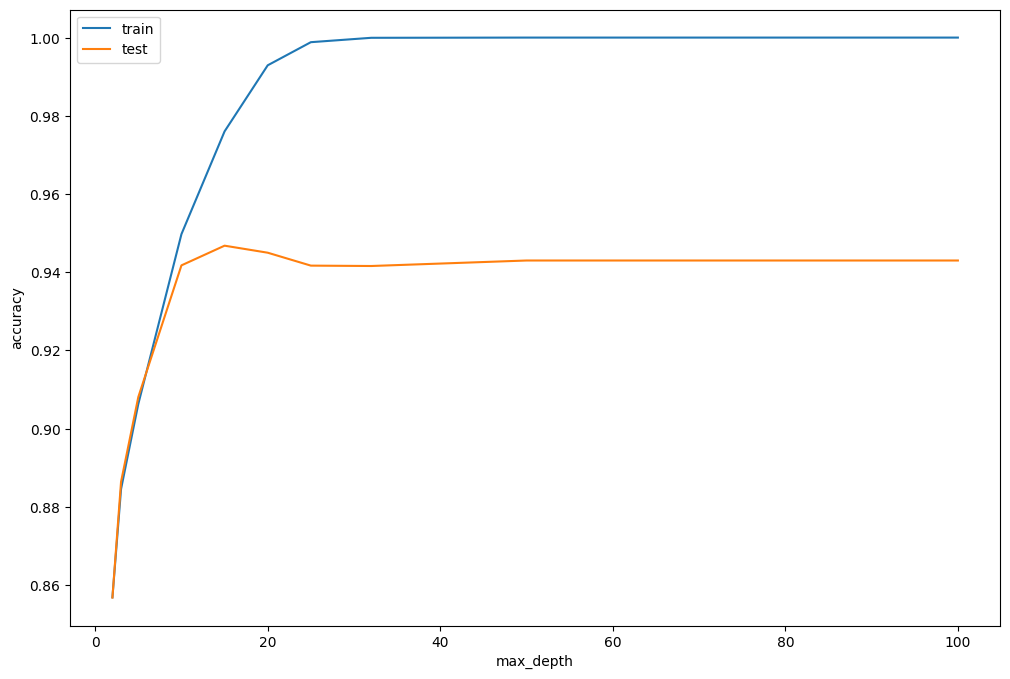

In [64]:
plt.figure(figsize=(12, 8))
plt.plot(depths, accuracies_train, depths, accuracies_test)
plt.legend(['train', 'test'])
plt.ylabel('accuracy')
plt.xlabel('max_depth')
plt.show()

Нам повезло выйти на ассимптоту на тесте. Однако так бывает далеко не всегда. Так что подбирать гипрепараметры для деревьев решений стоит осторожно

## **Возвращение к задаче**

### **Задание 20. (0.4 балла)**

- На кроссвалидации подберите оптимальные гиперпараметры для дерева решений *(по данным со всеми признаками -- не на модельном примере из теоретической вставки)*.
- Удалось ли улучшить качество предсказаний подбором гиперпараметров?

In [65]:
# you know what to do

dt = DecisionTreeClassifier(random_state=42)
param_grid = {
    'max_depth': np.arange(2,20, 2),
    'min_samples_leaf': np.arange(1,20,2),
    'min_samples_split': np.arange(2,20,2),
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_encoded, y_train)

print("Лучшие гиперпараметры:")
print(grid.best_params_)

print(f"\nЛучшее CV accuracy: {grid.best_score_:.4f}")

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.che

[CV] END criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=2; total time=   0.1s
[CV] END criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=2; total time=   0.1s
[CV] END criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=2; total time=   0.1s
[CV] END criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=2; total time=   0.1s
[CV] END criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=4; total time=   0.1s
[CV] END criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=4; total time=   0.1s
[CV] END criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=6; total time=   0.1s
[CV] END criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=4; total time=   0.1s
[CV] END criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=4; total time=   0.1s
[CV] END criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=2; total time=   0.1s
[CV] END criterion=g

In [66]:
best_dt = grid.best_estimator_

y_val_pred = best_dt.predict(X_val_encoded)
val_acc_best = accuracy_score(y_val, y_val_pred)

print(f"Accuracy на валидации (после подбора гиперпараметров): {val_acc_best:.4f}")


Accuracy на валидации (после подбора гиперпараметров): 0.9513


Показатель стал больше, чем у дефолтной модели без подбора гиперпараметров: было 0.9415, стало 0.9513 - супер!

### **Задание 21. (0.1 балла)**

- Сохраните лучшее дерево в pickle

*Мы просим это сделать, чтобы вы в случае чего не тратили время на переобучение, а могли банально подгрузить из файла*

In [67]:
with open('DT.pkl', 'wb') as f:
    pickle.dump(best_dt, f)

проверка, что все правильно сработало

In [68]:
with open('DT.pkl', 'rb') as f:
    best_dt_loaded = pickle.load(f)

In [69]:
y_val_pred = best_dt_loaded.predict(X_val_encoded)
val_acc_best = accuracy_score(y_val, y_val_pred)

print(f"Accuracy на валидации из пикла: {val_acc_best:.4f}")


Accuracy на валидации из пикла: 0.9513


# **Часть 3. Random Forest (4.25 балла)**

### **Задание 22. (0.05 балла)**
- Обучите случайный лес с параметрами по умолчанию

In [70]:
# Ваш код здесь
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_encoded, y_train)
y_val_pred = rf.predict(X_val_encoded)

acc_val = accuracy_score(y_val, y_val_pred)
print(f"Accuracy на валидации: {acc_val:.4f}")


Accuracy на валидации: 0.9614


Показатель лучше, чем при решающем дереве с подбором гиперпараметров 

### **Задание 23. (0.15 балла)**
- Выведите калибровочную кривую для полученного ансамбля

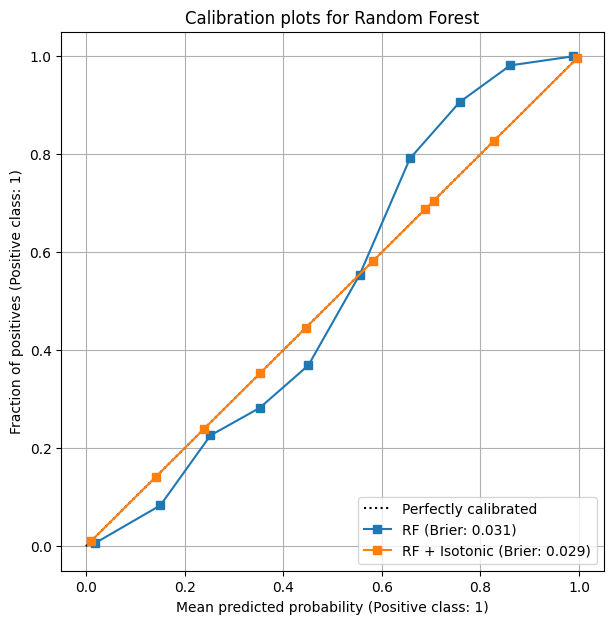

In [71]:
# Ваш код здесь
from sklearn.metrics import brier_score_loss

y_prob_rf = rf.predict_proba(X_val_encoded)[:, 1]
brier_rf = brier_score_loss(y_val, y_prob_rf)

iso_reg = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(y_prob_rf, y_val)
y_prob_iso = iso_reg.predict(y_prob_rf)
brier_iso = brier_score_loss(y_val, y_prob_iso)

fig, ax = plt.subplots(figsize=(7, 7))

# Калибровочная кривая RandomForest
CalibrationDisplay.from_predictions(
    y_val,
    y_prob_rf,
    n_bins=10,
    name=f"RF (Brier: {brier_rf:.3f})",
    ax=ax,
)
# Калиброванный Isotonic
CalibrationDisplay.from_predictions(
    y_val,
    y_prob_iso,
    n_bins=10,
    name=f"RF + Isotonic (Brier: {brier_iso:.3f})",
    ax=ax,
)

ax.set_title("Calibration plots for Random Forest")
ax.grid(True)
plt.show()


Синяя кривая похожа на зеленую из картинки ниже (центр распределения массивен), а оранжевая наслаивается на идеальную калибрацию

Похоже, мы немного недооцениваем высокие вероятности

<img src='https://habrastorage.org/r/w1560/getpro/habr/upload_files/510/4e0/63b/5104e063b62bd0ac6b87da44a3034aa5.png'>

Изображение взято из статьи ["predict_proba в Python не прогнозирует вероятности (и как с этим бороться)"](https://habr.com/ru/company/otus/blog/573924/) с Хабра

### **Задание 24. (0.4 балла)**

- Вспомните (или выведите), корректно ли деревья предсказывают вероятности?



```
Ваш ответ здесь
```



Вроде бы по умолчанию деревья не умеют предсказывать именно вероятность, для них она это просто доля объекта положительного класса в листе. ДЕеревья лучше предсказывают сами объекты

### **Задание 25. (0.15 балла)**
- Обучите логистическую регрессию так, чтобы она сошлась
- Отобразите её калибровочную кривую

<Figure size 800x600 with 0 Axes>

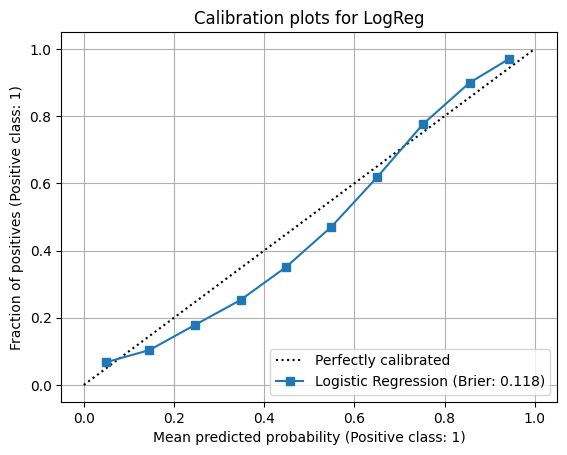

In [72]:
# Ваш код здесь
lr = LogisticRegression()
lr.fit(X_train_encoded, y_train)

y_prob = lr.predict_proba(X_val_encoded)[:, 1]
brier = brier_score_loss(y_val, y_prob)

plt.figure(figsize=(8,6))
CalibrationDisplay.from_estimator(
    lr,
    X_val_encoded,
    y_val,
    n_bins=10,
    name=f"Logistic Regression (Brier: {brier:.3f})",
)
plt.grid()
plt.title("Calibration plots for LogReg")
plt.show()

Тоже похож на зеленый график

Мы немного переоцениваем предсказанные низкие вероятности

### **Задание 26. (0.2 балла)**
- Покажите, почему считается, что логистическая регрессия корректно предсказывает вероятности?



```
Ваш ответ здесь
```

Потому что она изначально учится через минимизацию функционала и ее предсказания - это вероятность наступления события (объекта), в то время как дерево предсказывает именно объект

### **Задание 27. (0.35 балла)**

Предлагаем вам попробовать откалибровать вероятности обученного случайного леса!

- Откалибруйте вероятности, при помощи логистической и изотонической регрессий.
- Интерпретируйте полученные результаты

<Figure size 600x400 with 0 Axes>

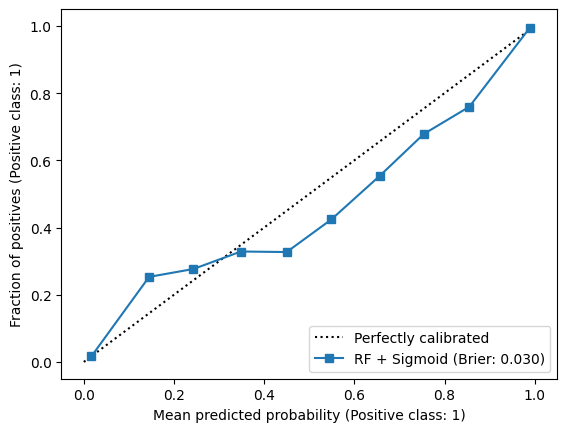

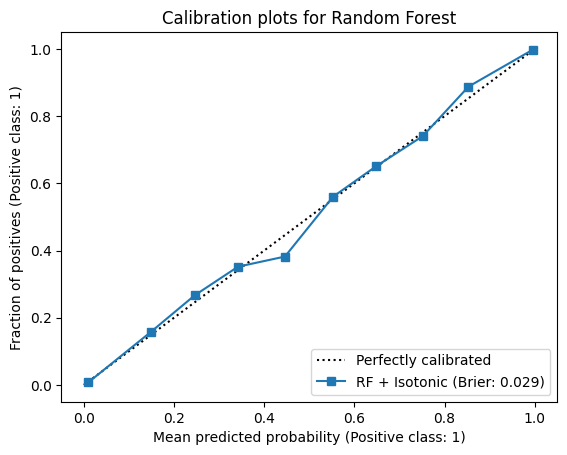

In [73]:
# Ваш код здесь
from sklearn.calibration import CalibratedClassifierCV

rf_isotonic = CalibratedClassifierCV(rf, cv=3, method="isotonic")
rf_sigmoid = CalibratedClassifierCV(rf, cv=3, method="sigmoid")

rf_sigmoid.fit(X_train_encoded, y_train)
rf_isotonic.fit(X_train_encoded, y_train)

y_prob_sigmoid = rf_sigmoid.predict_proba(X_val_encoded)[:, 1]
y_prob_isotonic = rf_isotonic.predict_proba(X_val_encoded)[:, 1]

brier_sigmoid = brier_score_loss(y_val, y_prob_sigmoid)
brier_isotonic = brier_score_loss(y_val, y_prob_isotonic)

plt.figure(figsize=(6,4))

CalibrationDisplay.from_estimator(
    rf_sigmoid,
    X_val_encoded,
    y_val,
    n_bins=10,
    name=f"RF + Sigmoid (Brier: {brier_sigmoid:.3f})"
)

CalibrationDisplay.from_estimator(
    rf_isotonic,
    X_val_encoded,
    y_val,
    n_bins=10,
    name=f"RF + Isotonic (Brier: {brier_isotonic:.3f})"
)

plt.title("Calibration plots for Random Forest")
plt.show()

Isotonic более приближенна к идеальной кабировке, бриеф тоже меньше = точнее вероястности. Sigmoid похожа на черную кривую с картинки выше, что означает что хвосты распределения слишком массивны. 

Также стоит отметить, что Isotonic через функцию IsotonicRegression была еще больше приближена к иделаьной калибровке (код выше)

### **Задание 28. (0.2 балла)**
- Опишите другие возвожные подходы к калибровке вероятностей (со ссылками на источники)



```
Ваш ответ здесь
```
https://alexanderdyakonov.wordpress.com/2020/03/27/проблема-калибровки-уверенности/
- Непараметрический метод гистограммной калибровки (Histogram Binning)
- Параметрическая калибровка Платта (Platt calibration)
- Логистическая регрессия в пространстве логитов
- Биннинг + параметрические методы: scaling-binning calibrator
- Деревья калибровки (Probability calibration trees)
- Ансамблирование в калибровках
- и так далее по этой статье, там много разных видов



### **Задание 29. (0.5 баллa)**

Проанализируйте лес.
- Посчитайте разброс и смещение полученного случайного леса (до калибровки).
- Оличаются ли они от полученных для дерева решений?
- Соответствуют ли полученные на реальных данных отличия (//совпадения) от тех, что должны быть в теории? По каким причинам?

In [74]:
# Ваш код здесь
error_rf, bias_rf, var_rf = bias_variance_decomp(
    rf,
    X_train_encoded.values, 
    y_train.values, 
    X_val_encoded.values,   
    y_val.values, 
    loss='0-1_loss',
    random_seed=42, 
    num_rounds=20 #очень долго бежал и не добежал, 20 минут, решила как-то оптимизировать
)
error_rf, bias_rf, var_rf

(np.float64(0.04084803921568628),
 np.float64(0.03944444444444444),
 np.float64(0.008681372549019607))


```
Ваш ответ здесь
```

У дерева было: 
- error_dt = 0.061766339869281046
- bias_dt= 0.040522875816993466
- var_dt= 0.04599313725490196

У леса: 
- error_rf = 0.04084803921568628
- bias_rf = 0.03944444444444444
- var_rf = 0.008681372549019607


В отличие от дерева, случайный лес показал значительно меньшую variance, что ожидаемо, так как ансамбли уменьшают разброс за счёт усреднения предсказаний множества деревьев. Bias у леса практически такой же, как у одного дерева, а ошибка  стала меньше. 

Эти результаты совпадают с теоретическими ожиданиями: ансамбли деревьев снижают variance без существенного увеличения bias, что улучшает общую точность модели на реальных данных.


### **Задание 30. (0.5 баллa)**

- Вычислите разложение ошибки для логистической регрессии (ванильной, которую вы обучили для решения задачи в задании 25, а не той, что использовали для калибровки)
- Сравните полученные результаты с предыдущими.
- Объясните природу этих результатов

In [75]:
# Ваш код здесь
error_lr, bias_lr, var_lr = bias_variance_decomp(
    lr,
    X_train_encoded.values,
    y_train.values,
    X_val_encoded.values,
    y_val.values,
    loss='0-1_loss',
    random_seed=42
)
error_lr, bias_lr, var_lr

(np.float64(0.15664133986928103),
 np.float64(0.1538235294117647),
 np.float64(0.021623366013071892))

Сравнить с предыдущими = сравнить с результатами дерева и леса? 

У лог регрессии: 
- error_lr = 0.15664133986928103
- bias_lr = 0.1538235294117647
- var_lr = 0.021623366013071892

По сравнению с деревом и лесом ошибка в разы больше, также bias больше (линейная модель ограничена в гибкости), variance меньше чем у дерева (предсказания мало зависят от выборки, стабильны)

### **Задание 31. (0.8 баллa)**

- Попробуйте подобрать оптимальные гиперпараметры леса, используя [RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html).

**Важно:**  

Хотя бы один из гиперпараметров перебирайте из распределения (например, `uniform` из `scipy.stats`)

In [76]:
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators': np.arange(50, 201, 10),
    'max_depth': randint(3, 21),
    'min_samples_split': uniform(0.01, 0.09),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

rand_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1, 
    verbose = 2
)

rand_search.fit(X_train_encoded, y_train)

print("Best parameters:", rand_search.best_params_)
print("Best CV score:", rand_search.best_score_)

best_rf = rand_search.best_estimator_
y_val_pred = best_rf.predict(X_val_encoded)

print("Accuracy на валидации с RCV:", accuracy_score(y_val, y_val_pred))


Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END bootstrap=False, max_depth=5, max_features=log2, min_samples_split=0.015077042112439022, n_estimators=120; total time=   5.2s
[CV] END bootstrap=False, max_depth=5, max_features=log2, min_samples_split=0.015077042112439022, n_estimators=120; total time=   5.3s
[CV] END bootstrap=False, max_depth=5, max_features=log2, min_samples_split=0.015077042112439022, n_estimators=120; total time=   5.3s
[CV] END bootstrap=False, max_depth=8, max_features=log2, min_samples_split=0.02636424704863906, n_estimators=90; total time=   5.4s
[CV] END bootstrap=False, max_depth=8, max_features=log2, min_samples_split=0.02636424704863906, n_estimators=90; total time=   4.8s
[CV] END bootstrap=False, max_depth=8, max_features=log2, min_samples_split=0.02636424704863906, n_estimators=90; total time=   4.9s
[CV] END bootstrap=True, max_depth=14, max_features=log2, min_samples_split=0.057228078846901405, n_estimators=160; total time=   6.1s


у нас результат уже был выше на дереве с подбором гиперпараметров - больше 95%

## **Случайный лес. Вставка теории**

На модельном примере посмотрим, склонен ли случайный лес к переобучению с ростом числа деревьев в композиции.

Возьмем 4 полезных признака из одного из предыдщущих заданий, напоминающих теорию

In [77]:
# замените X_train_enc на ваш трейн

cols_for_RF = ['age', 'Flight Distance', 'Online boarding', 'Inflight wifi service']
X_train_RF = X_train_encoded[cols_for_RF]
# а тест нам не понадобится, ведь можно получить OOB-estimate ошибки

clf = RandomForestClassifier(warm_start=True, oob_score=True, random_state=42)
errors = []

for n_estimators in range(1, 251, 5):
    clf.set_params(n_estimators=n_estimators)
    clf.fit(X_train_RF, y_train)

    errors.append(1 - clf.oob_score_)

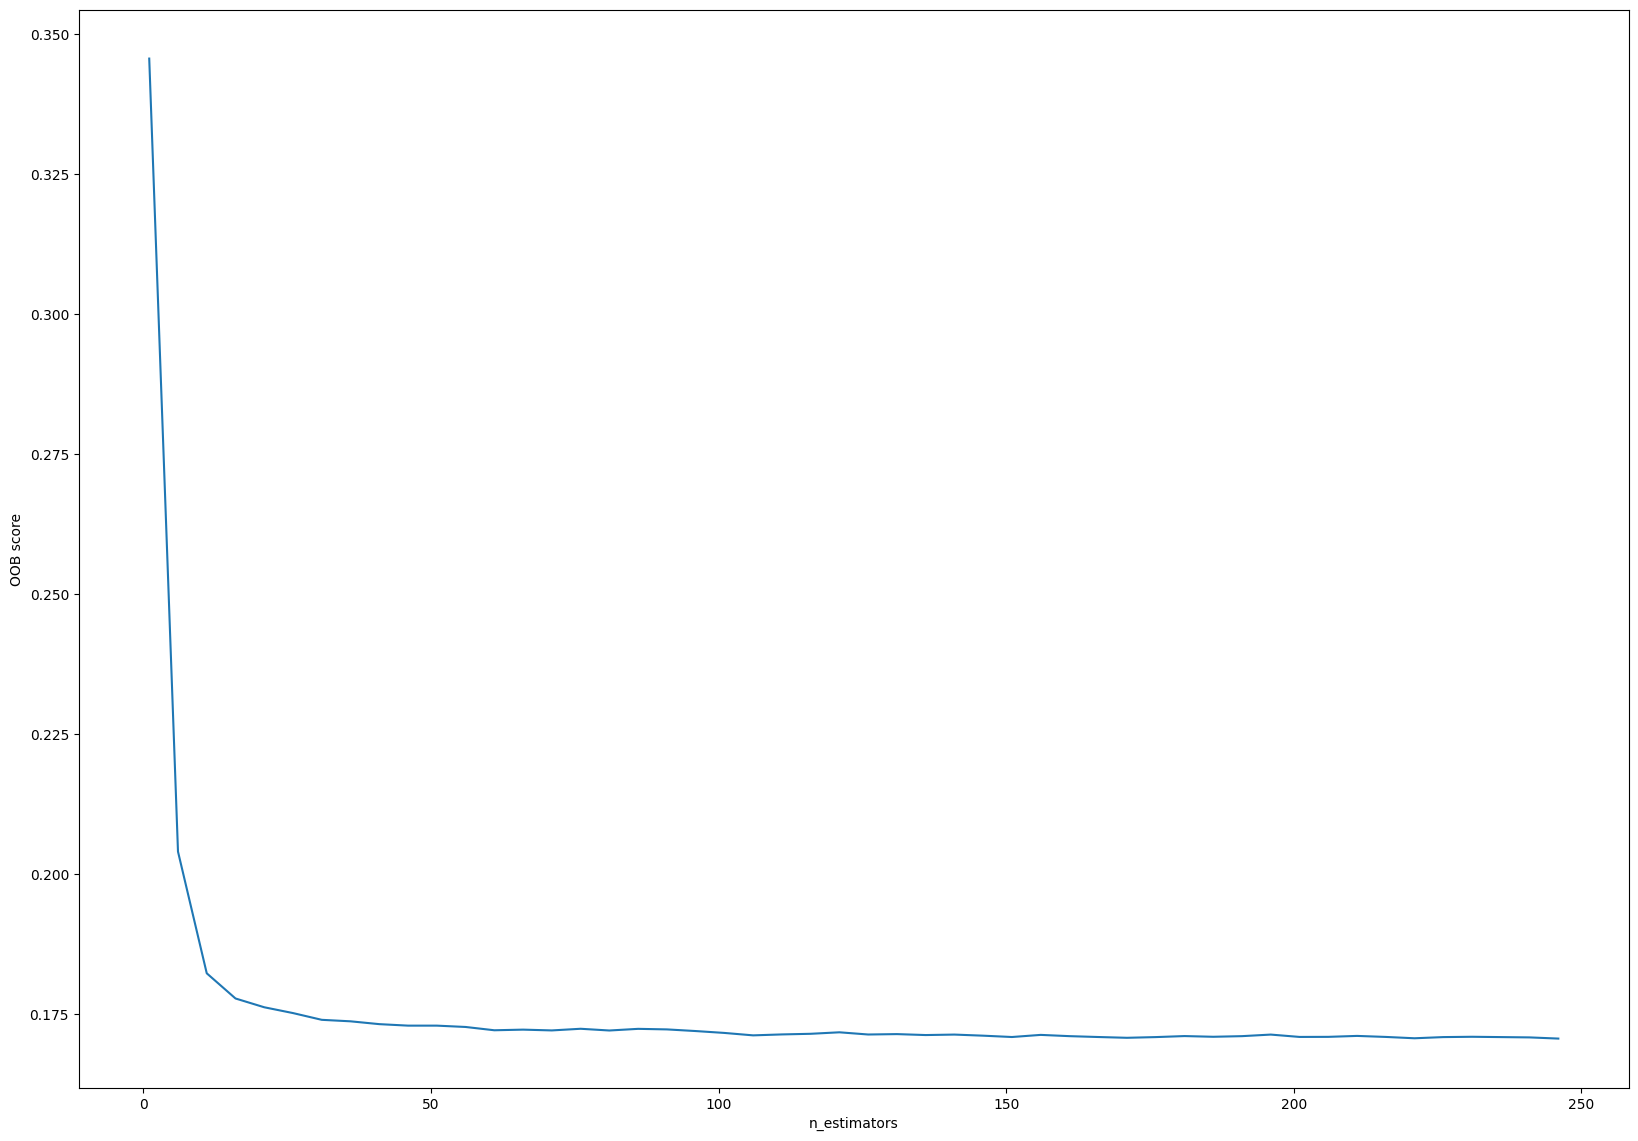

In [78]:
plt.figure(figsize=(20, 14))
plt.plot(range(1, 251, 5), errors)

plt.xlabel('n_estimators')
plt.ylabel('OOB score')
plt.show()

**Дисклеймер**: отсутствие переобучения с ростом числа деревьев вовсе не означает, что сама модель случайного леса не может быть переобучена. Базовые деревья такой композиции могут переобучаться. Значит, и вся композиция вполне способна оказаться переобученной

## **Возвращение к задаче**

### **Задание 32. (0.6 баллa)**

- Отобразите`feature_importances_` вашего лучшего случайного леса
- Сравните важности признаков для дерева решений и для случайного леса. Постройте диаграмму


/var/folders/hd/xbpxzxnn33d2wx_tj5j02_s40000gn/T/ipykernel_90089/3095970056.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='Spectral')


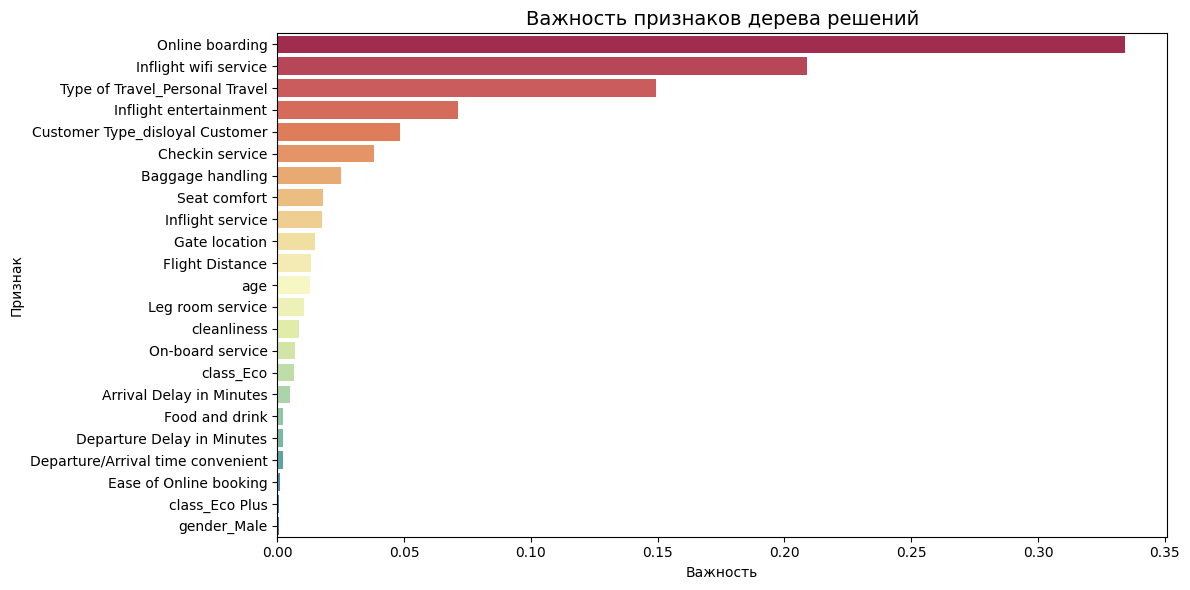

/var/folders/hd/xbpxzxnn33d2wx_tj5j02_s40000gn/T/ipykernel_90089/3095970056.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='Spectral')


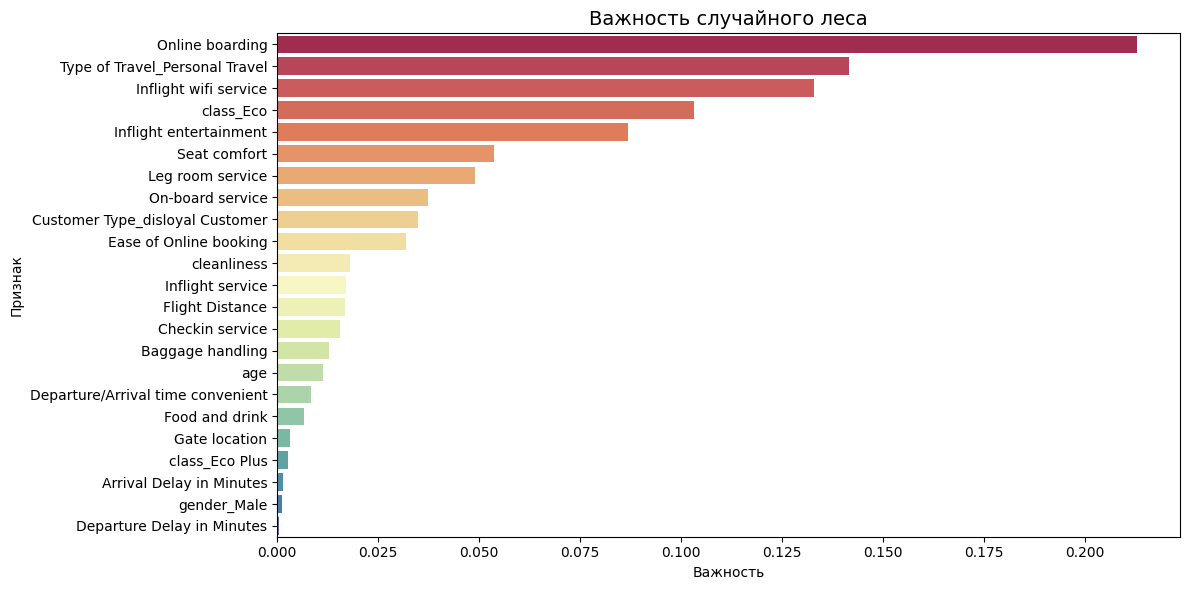

In [79]:
feature_importances = pd.Series(best_dt.feature_importances_, index=X_train_encoded.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='Spectral')
plt.title('Важность признаков дерева решений', fontsize=14)
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()


feature_importances = pd.Series(best_rf.feature_importances_, index=X_train_encoded.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='Spectral')
plt.title('Важность случайного леса', fontsize=14)
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()


Можно отметить, что топ-1 у двух моделей одинаковый, меняется местами топ-2 и топ-3 

### **Задание 33. (0.1 баллa)**

- Случайный лес, дающий лучший скор, [сохраните в pickle](https://scikit-learn.ru/stable/model_persistence.html)

In [80]:
with open('RF.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

### **Задание 34. (0.25 балла)**
- Интерпретируйте важности признаков с помощью SHAP.
- Опишите полученый график

**Важно:** Для подсчета используйте 1000 случайных объектов, иначе не дождетесь за приемлемое время

**Вам может помочь:** [Статья "Интерпретация моделей и диагностика сдвига данных: LIME, SHAP и Shapley Flow"](https://habr.com/ru/company/ods/blog/599573/) из блога ods.ai на Хабре

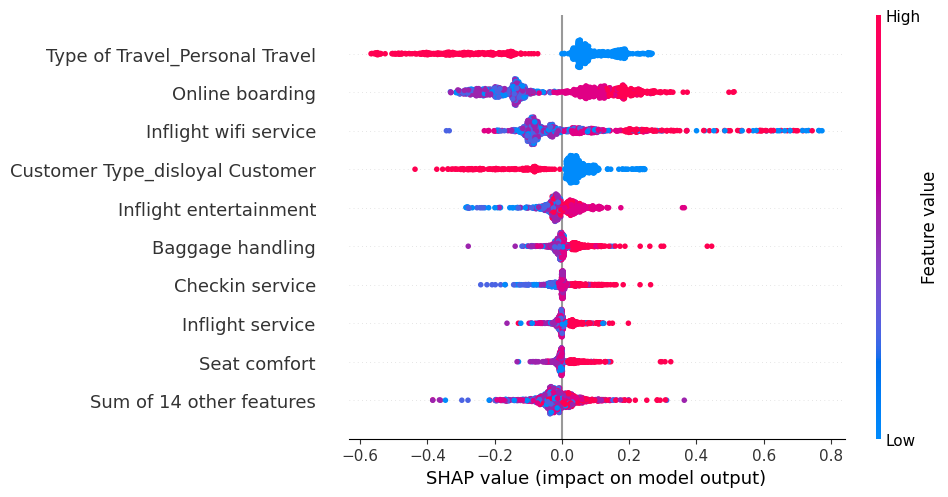

In [81]:
sample_idx = np.random.choice(X_train_encoded.shape[0], size=1000, replace=False)
X_sample = X_train_encoded.iloc[sample_idx].astype(float)

explainer = shap.TreeExplainer(best_dt)
shap_values_array = explainer.shap_values(X_sample)
expected_value = explainer.expected_value

# Конвертируем в Explanation объект
shap_values = shap.Explanation(
    values=shap_values_array,
    base_values=expected_value,
    data=X_sample
)

shap.plots.beeswarm(shap_values[:, :, 1] )

Как я поняла, чем краснее точки, тем большее значение имеет признак в этой точке. Слева - это таргет 0, а справа таргет 1. ТОлщина точек - прямопропорциональна кол-ву наблюдений

Тут видно, что Online Boarding топ-1 по влиянию, чем больше этот показатель, тем больше клиент склонен к 1 (то есть понравилось) и большее значение шапа дается этому признаку, а большое значение шапа в свою очередь свидетельствует о том, что если удалить этот признак, то предсказание значительно ухудшится. По второгму признаку (такая же логика у 4 признака) понятно, что если тип пушешествия не такой (то есть false), то ему больше понравится.

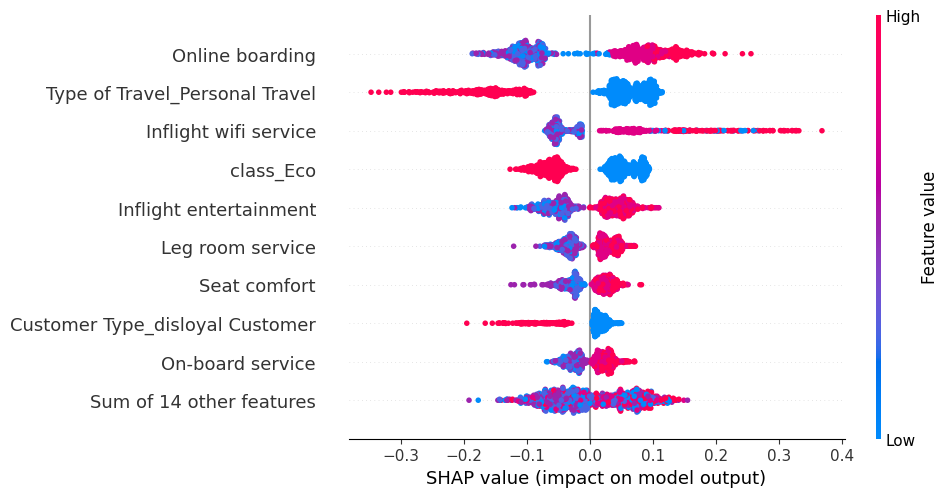

In [82]:
sample_idx = np.random.choice(X_train_encoded.shape[0], size=1000, replace=False)
X_sample = X_train_encoded.iloc[sample_idx].astype(float)

explainer = shap.TreeExplainer(best_rf)
shap_values_array = explainer.shap_values(X_sample)
expected_value = explainer.expected_value

shap_values = shap.Explanation(
    values=shap_values_array,
    base_values=expected_value,
    data=X_sample
)

shap.plots.beeswarm(shap_values[:, :, 1] )

Тут у нас такая же логика с Online boarding, но в этот раз тип путешествия вышел на 1 место, хотя на графике важностей 1 место делил Online Boarding у этих моделей. Чем выше Inflight wifi service тем больше вероятность, что клиенту понравится + также является важным шап признаком = влияет на предсказание модели

`Ваш ответ здесь`

### **Бонус (0.1 балл)**

- Изучите документацию библиотеки SHAP. Что ещё полезного в ней имеется?

`Ваш ответ здесь`

В рекомендуемой статье вообще много красивых визуализаций (waterfall plot, dependence plot), с шапом можно делать кластеризацию и диагностировать сдвиги данных, но, к сожалению, примеров кода не предоставлено и я не знаю, как это все самой реализовать, нужно рыться в документации

### **Бонус (0.5 балла)**

- Интерпретируйте важности признаков для одного прогноза с помощью LIME;
- Опишите полученный график для выбранного наблюдения

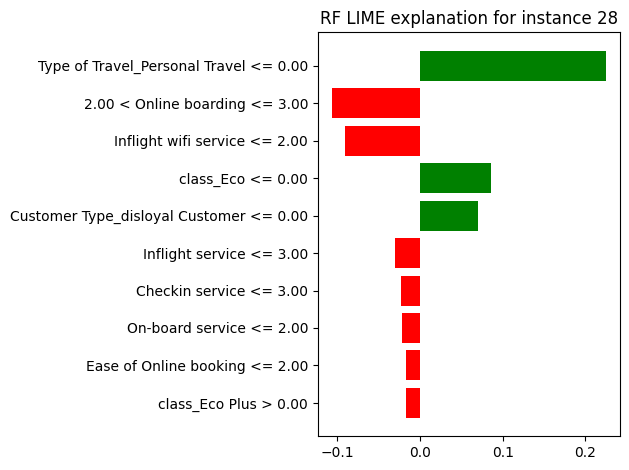

In [83]:
# Ваш код здесь
idx = 28
X_instance = X_train_encoded.iloc[idx]

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_encoded.values,
    feature_names = X_train_encoded.columns,
    class_names = ['neutral or dissatisfied', 'satisfied'], 
    mode = 'classification'
)

exp = explainer.explain_instance(
    data_row = X_instance.values,
    predict_fn = best_rf.predict_proba,
    num_features = 10  
)
exp.as_pyplot_figure()
plt.title(f'RF LIME explanation for instance {idx}')
plt.tight_layout()
plt.show()

Видно, что если тип был НЕ персональный путешественник, то это толкало к положиетльному классу (как и шап показывал), если оценка на Online Boarding 3, то это толкает в отрицательный класс и так далее

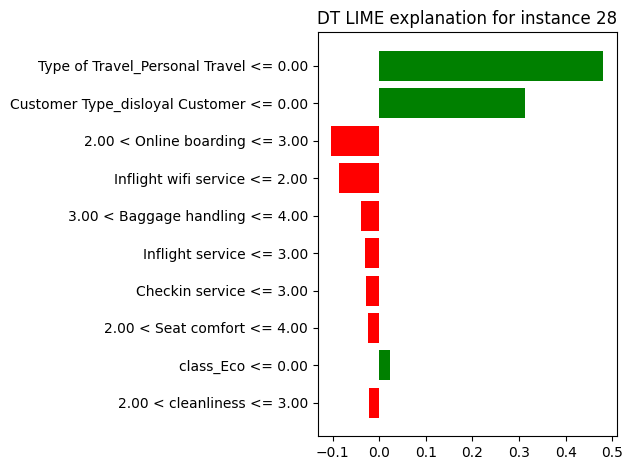

In [84]:
# Ваш код здесь
idx = 28
X_instance = X_train_encoded.iloc[idx]

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_encoded.values,
    feature_names = X_train_encoded.columns,
    class_names = ['neutral or dissatisfied', 'satisfied'], 
    mode = 'classification'
)

exp = explainer.explain_instance(
    data_row = X_instance.values,
    predict_fn = best_dt.predict_proba,
    num_features = 10  
)
exp.as_pyplot_figure()
plt.title(f'DT LIME explanation for instance {idx}')
plt.tight_layout()
plt.show()

Видно, что если тип был НЕ персональный путешественник и НЕ лояльный покупатель, то это толкало к положиетльному классу (как и шап показывал), если оценка на Online Boarding 3 и Inflight wifi service меньше 2 включительно, то это толкает в отрицательный класс и так далее

`Ваш ответ здесь`

# Обратная связь

Расскажите, как вам это домашнее задание. Было ли оно полезным? Научились ли вы чему то? Насколько сложным по 10-балльной шкале оно вам показалось? Сколько времени у вас ушло на его выполнение? Что следовало ещё в него включить? Было ли что-то лишнее?

Интересное дз, но очень много времени и сил ушло на выполнение - потратила часа 5, чтобы просто дойти до блока с построением деревьев... По итогу ушло два выходных на чисто выполнение этой домашки...

По сложности - баллов 6. Я не поняла, зачем нужна тестовая выборка, если с ней по итогу ничего не делалось. Плюс мне было неочевидно, нужно ли дублировать преобразования, что делались с тренировочной выборкой на валидационную? Очень долго промучалась с установкой graphviz, пришлось несколько раз перезапускать кернел, чтобы проверить, что все установилось (по итогу ничего не помогло)

Можно было еще к подбору гиперпараметров добавить прунинг - стрижку

Последние задания приходилось оч много ждать, чтобы все загрузилось и отработало, а если неправильно, то нужно было перезапускать и опять ждать(